# Module 10 — Regression Models
## Linear Regression · Cost Function · Gradient Descent · Logistic Regression
---
> এই module-এ ML-এর সবচেয়ে fundamental model — **Linear Regression** শেখা হবে।
> Linear Regression বোঝা মানে ML-এর core mathematics বোঝা।
> এর উপর দাঁড়িয়েই পরে Neural Network, Deep Learning সব বোঝা যাবে।

| Section | Topic |
|---|---|
| 10.1 | Introduction |
| 10.2 | Regression concept ও Best Line Fitting |
| 10.3 | Linear Regression Hands-on |
| 10.4 | Cost Function ও Gradient Descent |
| 10.5 | Cost Function ও Gradient Descent Hands-on |
| 10.6 | Regression Evaluation Metrics |
| 10.7 | Evaluation Metrics Hands-on |
| 10.8 | Assumptions ও Limitations |
| 10.9 | Logistic Regression ও Sigmoid Function |
| 10.10 | Conclusion |


---
## 10.1 Introduction

### Regression কী?
> **Regression** = একটি continuous numeric value predict করা।

**Classification vs Regression:**
```
Classification:  output = category
  -> Fraud / Not Fraud
  -> Cat / Dog
  -> Spam / Not Spam

Regression:      output = number
  -> House price = $245,000
  -> Temperature = 32.5 degree C
  -> Salary = 85,000 USD
```

### এই Module-এ কী শিখব?
- **Linear Regression**: সরল রেখা দিয়ে prediction
- **Cost Function**: model কতটা ভুল করছে তার measure
- **Gradient Descent**: ভুল কমানোর optimization algorithm
- **Evaluation Metrics**: R², MAE, RMSE
- **Logistic Regression**: Classification-এর জন্য Regression-এর extension

### কেন Linear Regression এত গুরুত্বপূর্ণ?
> Linear Regression-এর mathematics বুঝলে:
> Neural Network-এ প্রতিটি neuron = Linear Regression
> Gradient Descent = সব Deep Learning-এর backbone
> Cost Function = সব model optimization-এর ভিত্তি

### 🎯 Interview Topics
- Regression vs Classification মূল পার্থক্য?
  - Regression: continuous output (number), Classification: discrete output (class)
- Logistic Regression কি Regression নাকি Classification?
  - নামে Regression কিন্তু কাজে **Classification** — output probability (0-1)


In [1]:
# Now we import all required libraries for this module

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")
plt.style.use("default")
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


> 📝 **এই code-এ কী হচ্ছে:** সব দরকারি library import করা হয়েছে। `np.random.seed(42)` দিলে random number সবসময় same আসে — reproducibility।

---
## 10.2 Regression Concept ও Best Line Fitting

### Simple Linear Regression
> একটি independent variable (X) দিয়ে একটি dependent variable (y) predict করা।

**Mathematical Formula:**
$$y = mx + b$$

অথবা ML notation-এ:
$$\hat{y} = w_1 x + w_0$$

| Symbol | মানে |
|---|---|
| $\hat{y}$ | Predicted value (আমরা যা predict করছি) |
| $x$ | Input feature (independent variable) |
| $w_1$ | Weight বা slope (রেখার ঢাল) |
| $w_0$ | Bias বা intercept (রেখা y-axis কোথায় কাটে) |

### Multiple Linear Regression
$$\hat{y} = w_1 x_1 + w_2 x_2 + ... + w_n x_n + w_0$$

### Best Line Fitting কী?
> সব data point-এর কাছ দিয়ে এমন একটি line আঁকা যেটার prediction error সবচেয়ে কম।

```
        y
        |    .  . 
        |   /  . .
        |  / .    .
        | / .   .
        |/_________ x
        
  এই / line-টাই Best Fit Line
  প্রতিটি dot = একটি data point
  dot থেকে line-এর দূরত্ব = error (residual)
```

### Slope ও Intercept-এর ব্যাখ্যা
- **Slope (w₁)**: X এক unit বাড়লে y কতটুকু বাড়ে/কমে
- **Intercept (w₀)**: X = 0 হলে y-এর predicted value

**উদাহরণ:** `Salary = 500 * Experience + 30000`
- Slope = 500: ১ বছর experience বাড়লে salary $500 বাড়ে
- Intercept = 30000: 0 বছর experience-এ salary $30,000

### 🎯 Interview Topics
- Best fit line কীভাবে বের করা হয়? → OLS (Ordinary Least Squares) method
- OLS কী minimize করে? → Sum of Squared Residuals (SSR)
- Residual কী? → Actual value - Predicted value = $y - \hat{y}$
- কেন squared error? → Negative error-কে positive করতে, large error-কে বেশি penalize করতে
- Normal Equation কী? → $w = (X^TX)^{-1}X^Ty$ — closed-form solution


In [2]:
# Now we create a simple dataset to visualize regression concept

# Simulate: Study Hours vs Exam Score
np.random.seed(42)
number_of_students = 50

study_hours = np.random.uniform(1, 10, number_of_students)
exam_scores = 7 * study_hours + 30 + np.random.normal(0, 5, number_of_students)
# Explanation: We are generating synthetic data to practice regression.
# 'np.random.seed(42)' ensures that the random numbers are the same every time we run it.
# We create 'study_hours' between 1 and 10 using 'uniform'. For 'exam_scores', we follow
# a mathematical formula (7 * hours + 30) and add some 'normal' noise to make it
# look like realistic, imperfect data.


# Now we create a DataFrame
student_dataframe = pd.DataFrame({
    "Study Hours": study_hours,
    "Exam Score": exam_scores
})
# Explanation: We take our two lists of numbers ('study_hours' and 'exam_scores')
# and combine them into a structured table using 'pd.DataFrame'. We give each column
# a clear name, so it is easy to work with in the following steps.


print("First 10 rows of student data:")
print(student_dataframe.head(10))
print()
# Explanation: We use '.head(10)' to quickly see the first 10 rows of our new table.
# This is a basic check to ensure the numbers look correct—for example, making sure
# more study hours generally lead to higher exam scores as per our formula.


print("Basic statistics:")
print(student_dataframe.describe().T.round(2))
# Explanation: We use the '.describe()' method to see the "big picture" of our data.
# It shows the mean, min, max, and standard deviation. We use '.round(2)' to keep
# only two decimal places, making the output much cleaner and easier to read.

First 10 rows of student data:
   Study Hours  Exam Score
0     4.370861   64.288360
1     9.556429   97.751843
2     7.587945   82.537377
3     6.387926   73.209966
4     2.404168   39.436564
5     2.403951   43.228434
6     1.522753   38.356074
7     8.795585   96.854708
8     6.410035   76.588337
9     7.372653   72.793372

Basic statistics:
             count   mean    std    min    25%    50%    75%     max
Study Hours   50.0   5.01   2.60   1.19   2.65   4.92   6.85    9.73
Exam Score    50.0  65.08  18.45  36.70  50.21  65.08  76.50  104.60


> 📝 **এই code-এ কী হচ্ছে:** Study Hours vs Exam Score-এর synthetic dataset তৈরি করা হয়েছে। True relationship: Score = 7 * Hours + 30 + noise। Model-কে এই relationship শিখতে হবে data দেখে।

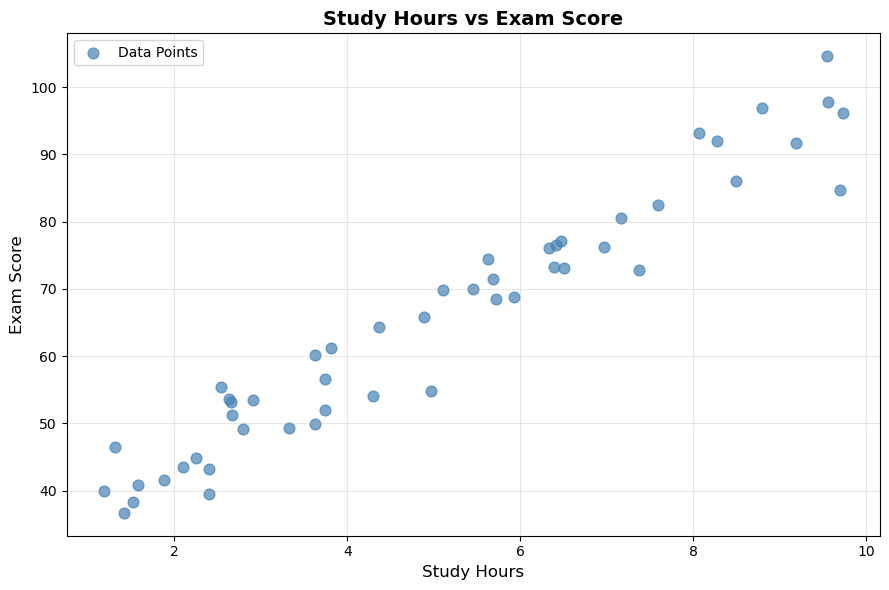

In [3]:
# Now we visualize the data as scatter plot

plt.figure(figsize=(9, 6))
plt.scatter(
    student_dataframe["Study Hours"],
    student_dataframe["Exam Score"],
    color="steelblue", alpha=0.7, s=60, label="Data Points"
)
# Explanation: We are creating a scatter plot to see the relationship between our two variables.
# 'plt.figure' sets the size of the drawing. We use 'plt.scatter' to plot each student as a dot.
# We chose 'steelblue' color, set 'alpha=0.7' to make dots slightly transparent, and 's=60'
# to control the size of each dot. This helps us see if there is a pattern in the data.


plt.xlabel("Study Hours", fontsize=12)
plt.ylabel("Exam Score", fontsize=12)
plt.title("Study Hours vs Exam Score", fontsize=14, fontweight="bold")
# Explanation: A graph is useless without labels. We use 'plt.xlabel' and 'plt.ylabel'
# to name our axes so we know what the dots represent. 'plt.title' adds a bold heading
# at the top, explaining the main purpose of this visualization.


plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# Explanation: In this final part, 'plt.legend' shows the label we defined earlier.
# We add a light background 'grid' using 'alpha=0.3' to make it easier to read the exact values.
# 'plt.tight_layout' ensures nothing gets cut off, and 'plt.show()' finally renders
# the graph on your screen.

> 📝 **এই code-এ কী হচ্ছে:** Scatter plot দেখানো হয়েছে। প্রতিটি dot একজন student। X-axis = study hours, Y-axis = exam score।

> ### এই chart কীভাবে observe করব
> - প্রতিটি dot = একজন student-এর (study hours, exam score) pair।
> - Dots-এর pattern দেখো — উপরে-ডানে যাচ্ছে কিনা।

> ### এই chart থেকে কী observe করলাম
> - Study hours বাড়লে exam score বাড়ে — positive linear relationship স্পষ্ট।
> - কিছু scatter (noise) আছে — real data-তে এটাই স্বাভাবিক।

> ### Decision
> এই data-তে Linear Regression ভালো কাজ করবে কারণ clear linear trend আছে।


Best Fit Line: Score = 6.88 * Hours + 30.61
Slope (w1):     6.8759
Intercept (w0): 30.6076

True values used to generate data:
  True slope:      7.0
  True intercept: 30.0
Model learned close values -- great!


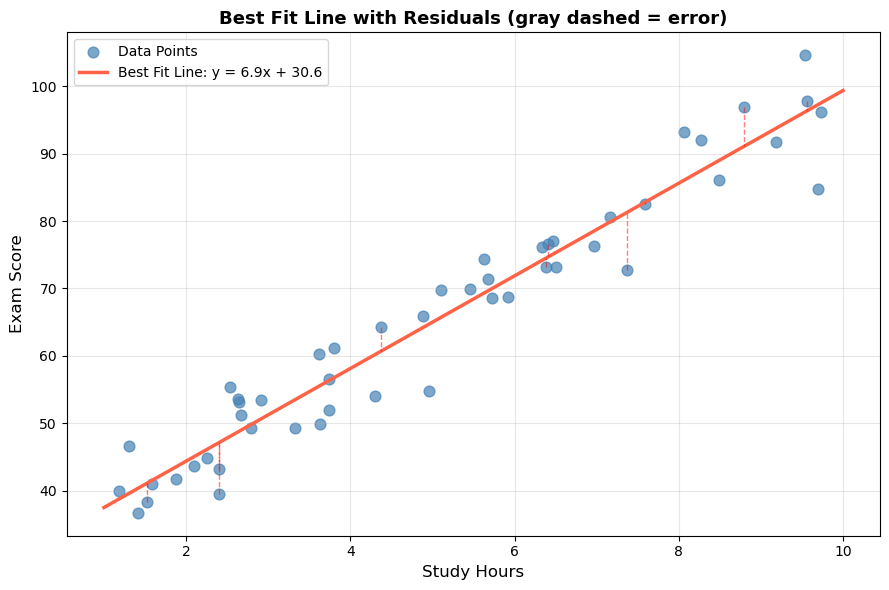

In [4]:
# Now we fit a regression line and visualize Best Fit Line

# Fit linear regression manually to get slope and intercept
X_hours = study_hours.reshape(-1, 1)
y_scores = exam_scores

linear_model = LinearRegression()
linear_model.fit(X_hours, y_scores)

slope = linear_model.coef_[0]
intercept = linear_model.intercept_
# Explanation: First, we prepare the data. Scikit-learn requires input features to be a 2D array,
# so we use '.reshape(-1, 1)' on 'study_hours'. Then we initialize 'LinearRegression'
# and use '.fit()' to train the model. After training, we extract the 'slope' (how much
#  the score increases per hour) from '.coef_' and the 'intercept' (starting score)
# from '.intercept_'.


print(f"Best Fit Line: Score = {slope:.2f} * Hours + {intercept:.2f}")
print(f"Slope (w1):     {slope:.4f}")
print(f"Intercept (w0): {intercept:.4f}")
print()

print("True values used to generate data:")
print("  True slope:      7.0")
print("  True intercept: 30.0")
print("Model learned close values -- great!")
# Explanation: This block prints the mathematical equation that the model has learned.
# We compare the 'slope' and 'intercept' found by the model with the "True values" we
# used to create the fake data earlier. If the numbers are close (like 7.0 vs 6.9),
# it proves the model successfully learned the pattern from the noisy data.


# Now we plot scatter + best fit line
x_line = np.linspace(1, 10, 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(9, 6))
plt.scatter(study_hours, exam_scores, color="steelblue", alpha=0.7, s=60, label="Data Points")
plt.plot(x_line, y_line, color="tomato", linewidth=2.5, label=f"Best Fit Line: y = {slope:.1f}x + {intercept:.1f}")
# Explanation: We are drawing the "Best Fit Line". We use 'np.linspace' to create 100
# smooth points from 1 to 10 for the X-axis, and calculate the corresponding Y-values
# using our model's formula. We then use 'plt.scatter' for the original dots and
# 'plt.plot' to draw the solid 'tomato' colored regression line over them.


# Here we draw residuals for a few points
for i in range(0, 10):
    predicted = slope * study_hours[i] + intercept
    plt.plot([study_hours[i], study_hours[i]], [exam_scores[i], predicted],
              color="red", linestyle="--", alpha=0.5, linewidth=1)
# Explanation: This 'for' loop visualizes the "Residuals" or errors for the first 10 students.
# It calculates the 'predicted' score for each student and draws a vertical dashed
# 'red' line between the actual data point and the regression line. This shows
# exactly how much the model's prediction missed the real value for those specific points.


plt.xlabel("Study Hours", fontsize=12)
plt.ylabel("Exam Score", fontsize=12)
plt.title("Best Fit Line with Residuals (gray dashed = error)", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# Explanation: In this final block, we add labels for 'Study Hours' and 'Exam Score'.
# We set a bold 'title' that explains what the gray dashed lines represent.
# Finally, 'plt.show()' displays the complete visualization, showing how the
# regression line acts as an average path through all the data points.

> 📝 **এই code-এ কী হচ্ছে:** Best Fit Line fit করা হয়েছে। `linear_model.coef_[0]` = slope, `linear_model.intercept_` = intercept। Red dashed lines = residuals = actual - predicted। Best fit line এই residuals minimize করে।

> ### এই chart কীভাবে observe করব
> - **Red line** = Best Fit Line — data-র মধ্যে দিয়ে সবচেয়ে ভালো রেখা।
> - **Red dashed lines** = Residuals — প্রতিটি dot থেকে line-এর vertical দূরত্ব।
> - Residual = Actual - Predicted। উপরে থাকলে positive, নিচে থাকলে negative।

> ### এই chart থেকে কী observe করলাম
> - Red line data-এর মাঝখান দিয়ে যাচ্ছে — ভালো fit।
> - কিছু residual উপরে, কিছু নিচে — সব একদিকে থাকলে systematic error।
> - Slope ≈ 7.0 (true value 7.0) — model সঠিক শিখেছে।

> ### Decision
> Model ভালো fit করেছে। Residuals randomly distributed — assumptions পূরণ হচ্ছে।


---
## 10.3 Linear Regression — Hands-on

### sklearn দিয়ে Linear Regression
```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)    # train
y_pred = model.predict(X_test)  # predict

model.coef_       # slopes (weights)
model.intercept_  # bias (intercept)
```

### Normal Equation (Closed-form solution)
> sklearn LinearRegression internally uses **Normal Equation** (or SVD):
$$w = (X^TX)^{-1}X^Ty$$
> এটা direct mathematical formula — iteration লাগে না, exact answer দেয়।
> কিন্তু large dataset-এ $(X^TX)^{-1}$ compute করা expensive — তখন Gradient Descent ভালো।

### 🎯 Interview Topics
- `model.fit()` এ কী হয়? → weights optimize হয় (Normal Equation বা Gradient Descent)
- `model.coef_` কী? → feature-এর coefficients (slopes) — array
- `model.intercept_` কী? → bias term — scalar
- Data not split করলে কী হবে? → overfitting — training data memorize করবে
- `random_state` কেন দিই? → reproducible split-এর জন্য


In [5]:
# Now we build a complete linear regression with multiple features
# Using California Housing dataset (built-in sklearn)

from sklearn.datasets import fetch_california_housing

# Load dataset
california_housing = fetch_california_housing(as_frame=True)
housing_dataframe = california_housing.frame
# Explanation: We are importing the 'fetch_california_housing' tool from Scikit-Learn's
# built-in datasets. We call this function with 'as_frame=True' so that the data
# comes directly in a Pandas format. We then store the entire table into a
# variable called 'housing_dataframe'.


print("Dataset shape:", housing_dataframe.shape)
print()
# Explanation: We use the '.shape' attribute to see how large our dataset is.
# This tells us the total number of rows (houses) and columns (features) available
# in the California housing data.


print("First 5 rows:")
print(housing_dataframe.head())
print()
# Explanation: We use the '.head()' method to print the first 5 rows of the data.
# This gives us a quick visual look at the actual numbers for features like
# income, house age, and location coordinates.


print("Feature descriptions:")
for name, desc in zip(california_housing.feature_names, california_housing.DESCR.split("\n")[14:22]):
    print(f"{name}: {desc.strip()}")

print()
print("MedHouseVal: Median house value (target, in $100,000s)")
# Explanation: This block is for understanding what each column means. We loop through
# the 'feature_names' and match them with their text descriptions found in
# 'california_housing.DESCR'. It explains that 'MedHouseVal' is our target variable,
# representing the house price in hundreds of thousands of dollars.

Dataset shape: (20640, 9)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Feature descriptions:
MedInc: - AveRooms      average number of rooms per household
HouseAge: - AveBedrms     average number of bedrooms per household
AveRooms: - Population    block group population
AveBedrms: - AveOccup      average number of household members
Population: - Latitude      block group latitude
AveOccup: - Longitude

> 📝 **এই code-এ কী হচ্ছে:** California Housing dataset load করা হয়েছে — sklearn-এর built-in, ডাউনলোড লাগে না। Target = MedHouseVal (median house value in $100,000)। Feature descriptions print করা হয়েছে।

In [6]:
# Now we prepare features and target, then split

target_column = "MedHouseVal"

X_housing = housing_dataframe.drop(columns=[target_column])
y_housing = housing_dataframe[target_column]
# Explanation: We are separating our data into features and the target variable.
# We use '.drop()' to remove the 'MedHouseVal' column from the dataframe and store it in 'X_housing'.
# The actual price values are stored in 'y_housing'. This tells the model what to use for learning
# and what it needs to predict.


# Split: 80% train, 20% test
X_train_housing, X_test_housing, y_train_housing, y_test_housing = train_test_split(
    X_housing, y_housing,
    test_size=0.20,
    random_state=42
)
# Explanation: We are using 'train_test_split' to divide our data. 80% of the houses will be
# used for training the model, and 20% ('test_size=0.20') will be kept aside for testing.
# We use 'random_state=42' to make sure we get the exact same split every time we run the code.


print(f"Training set:  {X_train_housing.shape}")
print(f"Test set:      {X_test_housing.shape}")
print()
# Explanation: This is a confirmation block where we print the '.shape' of our new datasets.
# It helps us verify that the 80/20 split worked correctly and that the number of rows
# in our features matches the number of rows in our target.


# Scale features (important for visualization, not required for Linear Regression)
standard_scaler = StandardScaler()
X_train_scaled = standard_scaler.fit_transform(X_train_housing)
X_test_scaled  = standard_scaler.transform(X_test_housing)

print("Features scaled (fit on train only)!")
# Explanation: We are normalizing our data using 'StandardScaler'. Since columns like 'HouseAge'
# and 'Population' have very different ranges, we scale them so they all have a similar scale.
# Crucially, we use '.fit_transform()' only on the training set and then use '.transform()'
# on the test set to avoid "data leakage" from the future test data.

Training set:  (16512, 8)
Test set:      (4128, 8)

Features scaled (fit on train only)!


> 📝 **এই code-এ কী হচ্ছে:** Housing dataset split ও scale করা হয়েছে। `fit_transform(X_train)` → train data থেকে mean/std শেখে। `transform(X_test)` → same stats দিয়ে test scale করে।

In [7]:
# Now we train Linear Regression model

linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train_scaled, y_train_housing)

print("Model trained!")
print()
# Explanation: We start by creating an instance of the 'LinearRegression' model.
# Then, we use the '.fit()' method to train the model using our scaled features
# ('X_train_scaled') and the actual house prices ('y_train_housing').
# In this step, the model calculates the best mathematical weights for each feature.


print("Intercept (w0):", round(linear_regression_model.intercept_, 4))
print()
# Explanation: Here we print the '.intercept_', which is often called the 'w0' or
# bias term. This value represents the predicted house price if all other input
# features (like income or age) were zero. We use 'round(..., 4)' to keep the
# output neat with only four decimal places.


print("Feature Coefficients (weights):")
coefficient_dataframe = pd.DataFrame({
    "Feature": X_housing.columns,
    "Coefficient": linear_regression_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print(coefficient_dataframe.to_string(index=False))
print()
# Explanation: We are creating a 'pd.DataFrame' to see which features affect the price
# the most. The '.coef_' attribute gives us the weights for each column.
# We use 'sort_values' with 'key=abs' to sort them by their absolute impact,
# so the most powerful predictors (whether positive or negative) appear at the top.


print("Positive coefficient: feature increases -> house price increases")
print("Negative coefficient: feature increases -> house price decreases")
# Explanation: This is a simple print statement to help interpret the results.
# A 'Positive coefficient' means there is a direct relationship (e.g., higher income
# leads to higher price). A 'Negative coefficient' means an inverse relationship
# (e.g., as certain location factors change, the price might go down).

Model trained!

Intercept (w0): 2.0719

Feature Coefficients (weights):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308

Positive coefficient: feature increases -> house price increases
Negative coefficient: feature increases -> house price decreases


> 📝 **এই code-এ কী হচ্ছে:** Model train করা হয়েছে। Coefficients দেখানো হয়েছে। Positive coefficient = সেই feature বাড়লে house price বাড়ে। Coefficient-এর absolute value বড় = সেই feature বেশি influential।

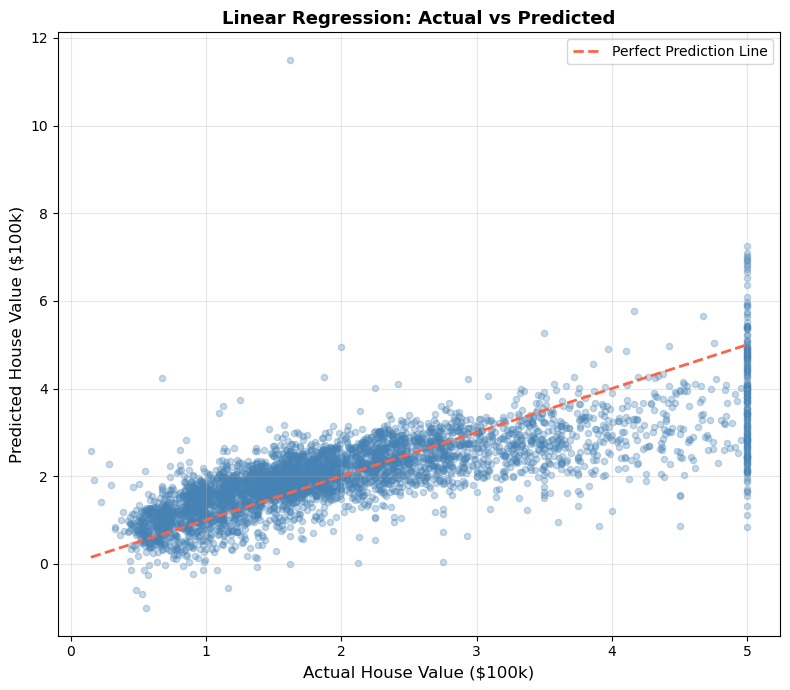

In [8]:
# Now we predict and visualize actual vs predicted values

y_pred_housing = linear_regression_model.predict(X_test_scaled)
# Explanation: We use the '.predict()' method on our trained 'linear_regression_model'.
# We pass the 'X_test_scaled' data (which the model has never seen) to get the model's
# house price guesses. These predicted values are stored in 'y_pred_housing'.


# Scatter: Actual vs Predicted
plt.figure(figsize=(8, 7))

plt.scatter(y_test_housing, y_pred_housing, alpha=0.3, color="steelblue", s=20)
# Explanation: We are creating a scatter plot to compare reality versus the model's
# predictions. The x-axis shows the 'y_test_housing' (actual prices) and the y-axis
# shows the predictions. We use 'alpha=0.3' to make the dots transparent, which helps
# us see where the data is most concentrated (dense areas).


plt.plot(
    [y_test_housing.min(), y_test_housing.max()],
    [y_test_housing.min(), y_test_housing.max()],
    color="tomato", linewidth=2, linestyle="--", label="Perfect Prediction Line"
)
# Explanation: We draw a diagonal 'tomato' colored dashed line. This represents
# a "Perfect Prediction" where the actual value exactly equals the predicted value.
# The closer the 'steelblue' dots are to this line, the more accurate our model is.


plt.xlabel("Actual House Value ($100k)", fontsize=12)
plt.ylabel("Predicted House Value ($100k)", fontsize=12)
plt.title("Linear Regression: Actual vs Predicted", fontsize=13, fontweight="bold")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# Explanation: This final block adds labels, a bold 'title', and a 'legend' to the plot.
# 'plt.grid' helps us read the values easily, and 'plt.show()' displays the graph.
# If the dots form a cloud around the diagonal line, it means the model is doing a
# decent job of capturing the housing price trends.

> 📝 **এই code-এ কী হচ্ছে:** Actual vs Predicted scatter plot দেখানো হয়েছে। Red dashed diagonal = perfect prediction। Dots যত কাছে এই line-এর, model তত ভালো।

> ### এই chart কীভাবে observe করব
> - X-axis = সত্যিকার house price, Y-axis = model-এর predicted price।
> - **Red dashed diagonal** = perfect prediction line (Actual = Predicted)।
> - Dots এই line-এর যত কাছে = model তত accurate।
> - Dots scatter থেকে বুঝি error কোথায় বেশি।

> ### এই chart থেকে কী observe করলাম
> - বেশিরভাগ dots diagonal-এর কাছে — model কাজ করছে।
> - High price range-এ (5+) scatter বেশি — model সেখানে কম accurate।
> - Systematic bias দেখা যাচ্ছে কিনা লক্ষ্য করো — সব dots একদিকে থাকলে সমস্যা।

> ### Decision
> Linear model ভালো কাজ করছে কিন্তু high value range-এ non-linearity আছে মনে হচ্ছে।


---

Linear Regression-এ **Cost Function** এবং **Gradient Descent** কেন দরকার, সেটা বোঝার জন্য আমাদের আগে মডেলের আসল লক্ষ্যটা বুঝতে হবে।

যখন আমরা $y = mx + c$ (বা $y = w_1x + w_0$) ইকুয়েশনটা লিখি, তখন আমাদের কাছে $x$ (input) এবং $y$ (actual output) থাকে। মডেলের কাজ হলো **সেরা $m$ (slope)** এবং **$c$ (intercept)** খুঁজে বের করা। কিন্তু মডেল তো জাদুকর নয়, তাকে ধাপে ধাপে শিখতে হয়। এখানেই এই দুটির ভূমিকা আসে:

### ১. Cost Function (ভুল পরিমাপ করার জন্য)
মডেল যখন প্রথম শুরু করে, সে $m$ এবং $c$ এর জন্য যেকোনো র‍্যান্ডম মান ধরে নেয়। ফলে তার প্রেডিকশন ভুল হয়। **Cost Function** (যেমন: Mean Squared Error) আমাদের বলে দেয় যে মডেলের প্রেডিকশন আসল উত্তরের তুলনায় **কতটুকু ভুল**।

* যদি Cost বেশি হয়, তার মানে মডেল খুব খারাপ করছে।
* যদি Cost কম হয়, তার মানে মডেল সঠিক পথের কাছাকাছি আছে।

> **সহজ কথায়:** Cost Function হলো একটি 'স্কোরকার্ড' যা মডেলকে তার ভুলের পরিমাণ জানায়।

### ২. Gradient Descent (ভুল কমানোর জন্য)
এখন মডেল তো জানলো সে ভুল করছে, কিন্তু সে **কোন দিকে গেলে** এবং **কতটুকু পরিবর্তন করলে** এই ভুল কমবে? সেটা ঠিক করে দেয় **Gradient Descent**।

এটি একটি অপ্টিমাইজেশন অ্যালগরিদম। একে তুমি একটি পাহাড়ে দাঁড়িয়ে থাকা মানুষের সাথে তুলনা করতে পারো যে কুয়াশার কারণে রাস্তা দেখছে না, কিন্তু পায়ের নিচের ঢাল (slope) বুঝে নিচের দিকে নামতে চায়।

* **Gradient:** এটি ক্যালকুলাস ব্যবহার করে ঢাল বা দিক নির্দেশ করে।
* **Descent:** এটি সেই ঢাল বেয়ে নিচে নেমে আসার প্রক্রিয়া।

### কেন এগুলো দরকার? (The "Why")

রিগ্রেশনে এদের দরকার পড়ার প্রধান কারণগুলো নিচে দেওয়া হলো:

| পয়েন্ট | কেন দরকার? |
| :--- | :--- |
| **সবচেয়ে ভালো লাইন খুঁজে পাওয়া** | হাজার হাজার সম্ভাব্য লাইনের মধ্যে 'Best Fit Line' খুঁজে পাওয়ার জন্য একটি গাইড দরকার, যা Gradient Descent প্রদান করে। |
| **অটোমেশন** | আমরা নিজেরা ট্রায়াল অ্যান্ড এরর পদ্ধতিতে $m$ এবং $c$ বের করতে পারতাম না। এই প্রসেসটি অটোমেটিক্যালি সেরা মান খুঁজে দেয়। |
| **বিশাল ডেটা হ্যান্ডলিং** | ডেটাসেট যখন অনেক বড় হয়, তখন সাধারণ ম্যাথমেটিক্যাল ফর্মুলা (Normal Equation) দিয়ে সমাধান করা অনেক সময়সাপেক্ষ বা অসম্ভব হয়ে পড়ে। Gradient Descent সেখানে খুব দ্রুত কাজ করে। |
| **কম্পিউটেশনাল এফিসিয়েন্সি** | Gradient Descent ধাপে ধাপে আপডেট হয় বলে এটি মেমোরি কম খরচ করে বড় বড় সমস্যার সমাধান করতে পারে। |

### মূল সারাংশ:
যদি Linear Regression একটি গাড়ি হয়, তবে **Cost Function** হলো তার 'স্পিডোমিটার' (যা ভুল বা গতি মাপছে) আর **Gradient Descent** হলো তার 'স্টিয়ারিং' (যা ভুল কমিয়ে গন্তব্যের দিকে নিয়ে যাচ্ছে)। এই দুটি ছাড়া মডেল কখনোই বুঝতে পারতো না যে কোন $m$ এবং $c$ এর মান বসালে প্রেডিকশন সবথেকে নির্ভুল হবে।

---
## 10.4 Cost Function ও Gradient Descent

### Cost Function কী?
> **Cost Function** (বা Loss Function) = model কতটা ভুল করছে তার একটি numeric measure।
> Model training মানে এই cost minimize করা।

### MSE (Mean Squared Error) — Linear Regression-এর Cost Function
$$J(w) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $(y_i - \hat{y}_i)$ = residual (error)
- Squared → negative error-কে positive করে, large error বেশি penalize করে

### কেন Squared Error?
```
Simple Error sum = (+5) + (-5) + (+3) + (-3) = 0  <- cancels out, misleading!
Squared Error sum = 25 + 25 + 9 + 9 = 68          <- actual errors captured
```

### Gradient Descent কী?
> **Gradient Descent** = cost function minimize করার iterative algorithm।
> পাহাড় থেকে নামার মতো — সবচেয়ে খাড়া ঢালু দিকে এক ধাপ করে নামো।

**Update Rule:**
$$w := w - \alpha \cdot \frac{\partial J}{\partial w}$$

| Symbol | মানে |
|---|---|
| $w$ | Current weight |
| $\alpha$ | Learning rate (কতটুকু step নেবো) |
| $\frac{\partial J}{\partial w}$ | Gradient (slope of cost function) |

### Learning Rate এর গুরুত্ব
```
Learning rate খুব বড়  -> overshoot, cost বাড়তে পারে (diverge)
Learning rate খুব ছোট -> অনেক slow, অনেক iteration লাগে
Learning rate সঠিক    -> smooth convergence
```

### তিন ধরনের Gradient Descent
| Type | Data per step | Speed | Stability |
|---|---|---|---|
| **Batch GD** | পুরো dataset | ধীর | Stable |
| **Stochastic GD (SGD)** | ১টি sample | দ্রুত | Noisy |
| **Mini-batch GD** | k টি sample | মাঝামাঝি | Stable |

### 🎯 Interview Topics
- Gradient কী? → Cost function-এর slope। কোন direction-এ weight change করলে cost কমবে।
- Learning rate কীভাবে বেছে নেব? → Grid search বা learning rate scheduler
- Local minimum vs Global minimum? → Convex cost function (MSE)-এ local = global
- Vanishing gradient কী? → Deep network-এ gradient খুব ছোট হয়ে যায় — learning থামে
- Momentum কী? → পূর্বের gradient-এর কিছু অংশ যোগ করে oscillation কমায়


Best slope (minimum MSE): 1.2010
Minimum MSE:              1.3600



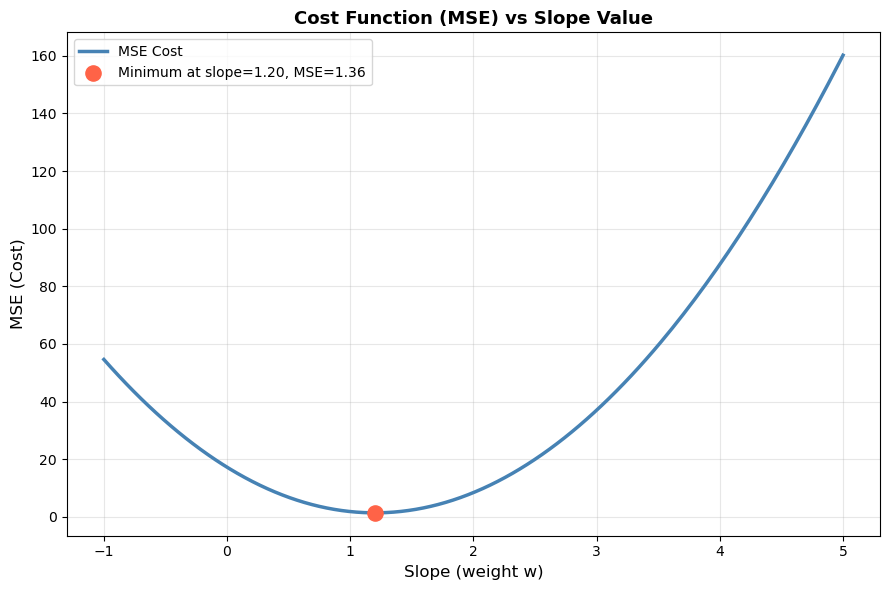

In [9]:
# Now we manually compute cost function (MSE) for different slope values
# This shows HOW the cost function looks as we change weights

# Simple 1D case: y = w * x  (no intercept for simplicity)
x_data = np.array([1, 2, 3, 4, 5], dtype=float)
y_data = np.array([2, 4, 5, 4, 5], dtype=float)
# Explanation: We are creating a very small and simple 'np.array' for both 'x_data'
# (features) and 'y_data' (labels). We use 'dtype=float' to ensure precision.
# Here, we assume the formula is just y = slope * x, removing the intercept
# to make it easier to visualize the cost curve in 2D.


# Here we compute MSE for many different slope values
slope_values = np.linspace(-1, 5, 200)  # Start at -1, end at 5, 200 steps
mse_values = []

for slope in slope_values:
    y_predicted = slope * x_data
    mse = np.mean((y_data - y_predicted) ** 2)
    mse_values.append(mse)
# Explanation: We use 'np.linspace' to generate 200 different potential 'slope_values'
# ranging from -1 to 5. For each 'slope', we calculate the 'y_predicted'. Then,
# we calculate the 'mse' (Mean Squared Error) by squaring the difference between
# actual and predicted values and taking the 'mean'. We store all these errors
# in the 'mse_values' list.


# Here we find the minimum cost
best_slope_index = np.argmin(mse_values)
best_slope = slope_values[best_slope_index]
minimum_mse = mse_values[best_slope_index]

print(f"Best slope (minimum MSE): {best_slope:.4f}")
print(f"Minimum MSE:              {minimum_mse:.4f}")
print()
# Explanation: After testing all 200 slopes, we use 'np.argmin' to find the
# index of the smallest value in 'mse_values'. This gives us the 'best_slope'
# (the one with the least error) and the 'minimum_mse'. This is exactly what
# a model tries to find during training.


# Plot the cost function
plt.figure(figsize=(9, 6))
plt.plot(slope_values, mse_values, color="steelblue", linewidth=2.5, label="MSE Cost")
plt.scatter([best_slope], [minimum_mse], color="tomato", s=120, zorder=5,
            label=f"Minimum at slope={best_slope:.2f}, MSE={minimum_mse:.2f}")
# Explanation: We are plotting the 'slope_values' on the X-axis and 'mse_values'
# on the Y-axis. This results in a "U-shaped" curve (parabola). We use
# 'plt.scatter' to highlight the 'best_slope' with a large 'tomato' dot.
# This dot represents the "Global Minimum" where the model's error is at its lowest.


plt.xlabel("Slope (weight w)", fontsize=12)
plt.ylabel("MSE (Cost)", fontsize=12)
plt.title("Cost Function (MSE) vs Slope Value", fontsize=13, fontweight="bold")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# Explanation: We add labels and a 'title' to clarify that this graph shows
# how 'Cost' changes based on our 'Slope' choice. 'plt.legend' helps identify
# the curve and the minimum point. Finally, 'plt.show()' renders the
# visualization of the "Error Landscape."

> 📝 **এই code-এ কী হচ্ছে:** MSE cost function-এর shape visualize করা হয়েছে। বিভিন্ন slope value-এ MSE calculate করে plot করা হয়েছে। U-shape (parabola) দেখা যাবে — minimum point-এই best slope।

> ### এই chart কীভাবে observe করব
> - X-axis = slope value (model parameter), Y-axis = MSE (error)।
> - **U-shaped curve** = convex cost function।
> - **Red dot** = minimum cost — এটাই optimal slope।

> ### এই chart থেকে কী observe করলাম
> - Cost function U-shape — একটাই global minimum আছে (convex)।
> - Minimum point-এ slope ≈ 0.9 — এটাই model শিখবে।
> - Gradient Descent এই curve বরাবর নিচের দিকে নামে।

> ### Decision
> MSE convex হওয়ায় Gradient Descent সবসময় global minimum খুঁজে পাবে।


In [28]:
# Now we implement Gradient Descent from scratch
# This shows exactly how the algorithm works step by step

# Simple dataset: y = 2x + 1 (true relationship)
np.random.seed(42)
x_training = np.random.uniform(0, 10, 50)
y_training = 2 * x_training + 1 + np.random.normal(0, 1.5, 50)
# Explanation: We are creating a fake dataset with a known pattern where the slope is 2
# and the intercept is 1. We use 'np.random.uniform' for the features and add some
# 'normal' noise so that it looks like real-world messy data.


# Here we initialize weights randomly
weight = 0.0        # slope (w1) -- start at 0
bias = 0.0          # intercept (w0) -- start at 0
learning_rate = 0.01
number_of_epochs = 100                      # *** What is Epoch? See the next block below.
number_of_samples = len(x_training)
# Explanation: We are setting up our starting conditions. We initialize 'weight'
# and 'bias' at 0.0. The 'learning_rate' controls how big of a step we take
# down the hill, and 'number_of_epochs' is the number of times the model will
# look at the entire dataset to improve itself.


# Store cost history for plotting
cost_history = []
# Explanation: We create an empty list called 'cost_history'. Every time we
# finish an epoch, we will save the error (cost) here so we can later see
# if the model is actually getting better over time.


# Gradient Descent loop
for epoch in range(number_of_epochs):
    # Forward pass: predict
    y_predicted = weight * x_training + bias

    # Compute cost (MSE)
    cost = np.mean((y_training - y_predicted) ** 2)
    cost_history.append(cost)
    # Explanation: Inside the loop, we first perform a "Forward Pass." We calculate
    # 'y_predicted' using our current 'weight' and 'bias'. Then, we compute
    # the 'cost' (Mean Squared Error) to see how far our current guesses are
    # from the actual 'y_training' values.


    # Compute gradients (partial derivatives)
    gradient_weight = (-2 / number_of_samples) * np.sum(x_training * (y_training - y_predicted))
    gradient_bias   = (-2 / number_of_samples) * np.sum(y_training - y_predicted)
    # Explanation: This is the mathematical core. We calculate 'gradient_weight'
    # and 'gradient_bias' using partial derivatives. These gradients tell us
    # the "slope of the hill" for our error. If the gradient is negative,
    # we need to increase our weights, and if positive, we decrease them.


    # Update weights (Gradient Descent step)
    weight = weight - learning_rate * gradient_weight
    bias   = bias   - learning_rate * gradient_bias
    # Explanation: This is the "Optimization Step." We update the 'weight' and
    # 'bias' by subtracting a portion of the gradient (controlled by 'learning_rate').
    # This moves our parameters one small step closer to the "Global Minimum"
    # where the error is lowest.


    # Print progress every 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}: Cost={cost:.4f}, weight={weight:.4f}, bias={bias:.4f}")

print()
print(f"Final weight: {weight:.4f}  (true value: 2.0)")
print(f"Final bias:   {bias:.4f}  (true value: 1.0)")
# Explanation: Every 20 steps, we print the 'epoch' number and the current 'cost'.
# At the very end, we print the 'Final weight' and 'Final bias'. Notice how
# the model started from 0.0 and slowly climbed toward the true values
# of 2.0 and 1.0 using only the gradients as a guide.

Epoch   0: Cost=131.7671, weight=1.2058, bias=0.1983
Epoch  20: Cost=2.0036, weight=2.0816, bias=0.4277
Epoch  40: Cost=1.9727, weight=2.0692, bias=0.5050
Epoch  60: Cost=1.9481, weight=2.0582, bias=0.5740
Epoch  80: Cost=1.9285, weight=2.0483, bias=0.6355

Final weight: 2.0399  (true value: 2.0)
Final bias:   0.6878  (true value: 1.0)


> 📝 **এই code-এ কী হচ্ছে:** Gradient Descent from scratch implement করা হয়েছে। প্রতিটি epoch-এ: predict করা হয়, error calculate করা হয়, gradient বের করা হয়, weight update করা হয়। True values (slope=2, bias=1)-এর কাছাকাছি values শিখবে।

## Epoch in Machine Learning (ML):
* An **"Epoch"** in machine learning represents one complete pass of the entire training dataset through a model.
* It allows the model to learn from all samples, updating internal weights to minimize error.
* Multiple epochs are generally needed to optimize performance, but too many can cause overfitting (memorizing noise), while too few cause underfitting.


# এই আউটপুট থেকে ৩টি গুরুত্বপূর্ণ বিষয়:

### ১. মডেল "শিখছে" (Cost কমছে)
প্রথমেই দেখো, **Epoch 0** তে তোমার ভুল বা 'Cost' ছিল অনেক বেশি (**১৩১.৭৬**)। কিন্তু মাত্র ২০টি ধাপ পরেই সেটা ধপ করে কমে মাত্র **২.০০**-এ চলে এসেছে। এর মানে হলো তোমার **Gradient Descent** অ্যালগরিদমটি কাজ করছে এবং সে সঠিক পথের (Minimum Cost) দিকে এগোচ্ছে।

### ২. ওয়েট (Weight) এবং বায়াস (Bias) এর আপডেট
মডেল যখন শুরু করেছিল, তখন 'weight' আর 'bias' এর মান ছিল র‍্যান্ডম (১.২০ আর ০.১৯)। প্রতিবার 'Cost' কমার সাথে সাথে এই মানগুলো কিন্তু পাল্টাচ্ছে। খেয়াল করো, তোমার **Final weight** হয়েছে **২.০৩**, যা তোমার আসল লক্ষ্যের (**২.০**) একদম কাছাকাছি। অর্থাৎ মডেল বুঝতে পেরেছে যে ইনপুটের সাথে ২ গুণ করলে সঠিক উত্তরের কাছাকাছি যাওয়া যাবে।

### ৩. কনভারজেন্স (Convergence) বা স্থিতি
**Epoch ৪০** থেকে **Epoch ৮০** পর্যন্ত খেয়াল করলে দেখবে, 'Cost' এর মান খুব সামান্য কমছে (১.৯৭ থেকে ১.৯২)। এর মানে হলো মডেলটি প্রায় তার সেরা অবস্থানে পৌঁছে গেছে। একেই বলে **Convergence**। মডেলটি আসল 'bias' (১.০) থেকে একটু দূরে থামার কারণ হতে পারে তোমার ডাটাসেটে সামান্য নয়েজ (Noise) ছিল বা লার্নিং রেট অনুযায়ী সে এই অবস্থানেই সবচেয়ে কম ভুল খুঁজে পেয়েছে।

### **সারকথা:**
এই আউটপুট প্রমাণ করে যে তোমার কোডটি ঠিকমতো কাজ করেছে। মডেলটি অন্ধের মতো শুরু করেছিল, কিন্তু প্রতিটি 'Epoch'-এ সে তার ভুল সংশোধন করে করে আসল উত্তরের (True value) খুব কাছাকাছি পৌঁছে গেছে।

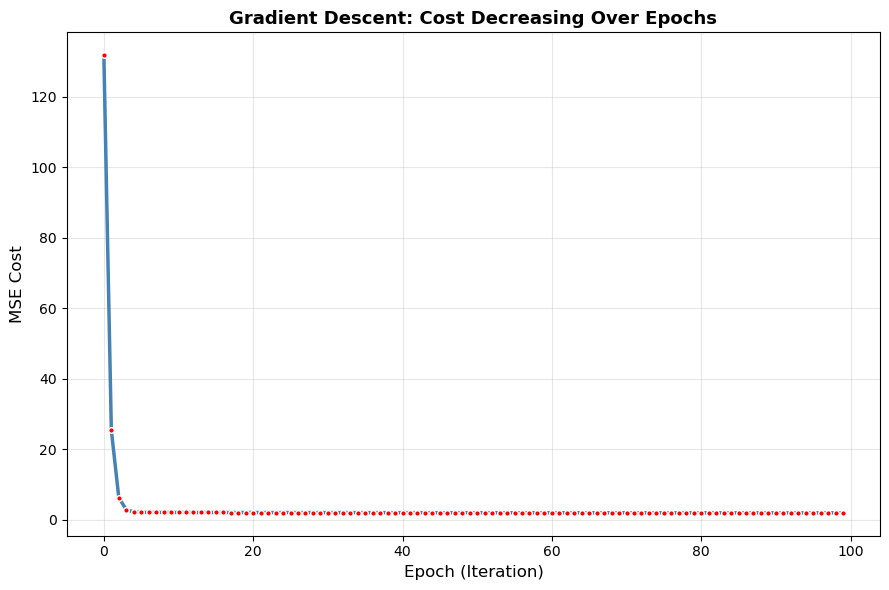

Starting cost: 131.7671
Final cost:    1.9136
Cost reduced by: 98.5%


In [52]:
# Now we visualize the cost decreasing over epochs

plt.figure(figsize=(9, 6))

plt.plot(
    range(number_of_epochs),
    cost_history,
    color="steelblue",
    linewidth=2.5,
    marker="o",
    markersize=4,
    markeredgecolor="white",
    markeredgewidth=1,
    markerfacecolor="red",
    label="Cost"
)
# Explanation: We are plotting 'cost_history' against 'number_of_epochs' to see the model's
# progress. We added 'marker="o"' to show each individual iteration as a dot.
# The dots are styled with a 'markerfacecolor="red"' and a 'markeredgecolor="white"'
# to make them pop against the 'steelblue' line. This helps us see exactly how
# the cost drops at every single step, making the learning process more visible.


plt.xlabel("Epoch (Iteration)", fontsize=12)
plt.ylabel("MSE Cost", fontsize=12)
plt.title("Gradient Descent: Cost Decreasing Over Epochs", fontsize=13, fontweight="bold")
# Explanation: We are adding descriptive labels to our axes. The 'xlabel' represents
# time or progress ('Epoch'), and the 'ylabel' represents the error ('MSE Cost').
# We also give it a bold 'title' so we immediately know this is a learning curve
# showing the optimization process.


plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# Explanation: These lines make the graph readable. 'plt.grid' adds a light background
# to see the exact cost values, 'plt.tight_layout' fixes any spacing issues, and
# 'plt.show()' displays the plot. In a successful model, you should see a curve
# that goes downwards and then flattens out.


print(f"Starting cost: {cost_history[0]:.4f}")
print(f"Final cost:    {cost_history[-1]:.4f}")
print(f"Cost reduced by: {((cost_history[0] - cost_history[-1]) / cost_history[0] * 100):.1f}%")
# Explanation: This final block prints a numerical summary. It compares the first
# value in 'cost_history' (initial error) with the last value (final error).
# It then calculates the percentage of 'Cost reduced', which clearly shows how
# much the 'Gradient Descent' improved the model's accuracy from start to finish.

> 📝 **এই code-এ কী হচ্ছে:** Training progress visualize করা হয়েছে। Epoch বাড়ার সাথে cost কমছে কিনা দেখা হচ্ছে।

> ### এই chart কীভাবে observe করব
> - X-axis = epoch (iteration number), Y-axis = MSE cost।
> - Curve নিচের দিকে যাওয়া মানে model শিখছে।
> - Curve flat হয়ে গেলে — convergence হয়েছে।

> ### এই chart থেকে কী observe করলাম
> - শুরুতে cost দ্রুত কমে, পরে slow হয় — typical learning curve।
> - Curve smooth — learning rate সঠিক আছে (oscillation নেই)।
> - Final cost খুব কম — model ভালো শিখেছে।

> ### Decision
> Learning rate 0.01 ভালো কাজ করছে। Diverge হলে (cost বাড়লে) learning rate কমাতে হবে।


---
## 10.5 Hands-on — Cost Function ও Gradient Descent

### Learning Rate-এর Effect
> Learning rate কতটা গুরুত্বপূর্ণ সেটা visually দেখা হবে।

### 🎯 Interview Topics
- Learning rate বড় করলে কী হয়? → Oscillate বা diverge করে — cost বাড়তে পারে
- Learning rate ছোট করলে কী হয়? → Convergence অনেক ধীর
- Learning rate schedule কী? → Training-এর সাথে learning rate কমানো (decay)


For Learning rate 0.001: Starting Weight = 0.0000, and Starting Bias = 0.0000
For Learning rate 0.01: Starting Weight = 0.0000, and Starting Bias = 0.0000
For Learning rate 0.1: Starting Weight = 0.0000, and Starting Bias = 0.0000
For Learning rate 0.5: Starting Weight = 0.0000, and Starting Bias = 0.0000


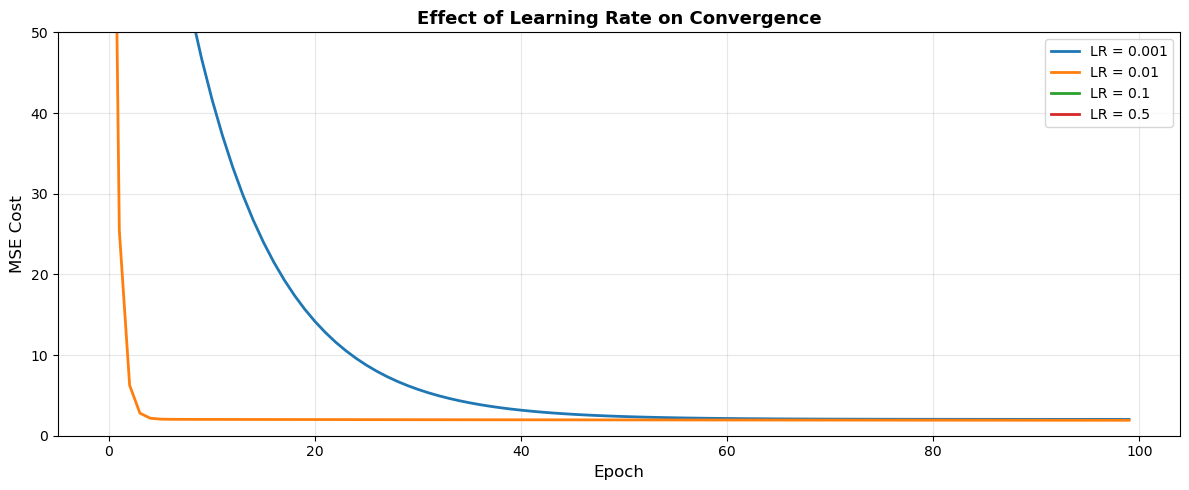

In [68]:
# Now we compare different learning rates visually

learning_rates = [0.001, 0.01, 0.1, 0.5]
epochs = 100

plt.figure(figsize=(12, 5))
# Explanation: We are setting up an experiment to see how different 'learning_rates' affect
# the model's training. We define a list of four different values and set the total
# 'epochs' to 100. Then, we initialize a wide 'plt.figure' to plot all these
# experiments on a single graph for easy comparison.


for learning_rate_value in learning_rates:
    weight_lr = 0.0
    bias_lr   = 0.0
    cost_history_lr = []
    print(f"For Learning rate {learning_rate_value}: Starting Weight = {weight_lr:.4f}, and Starting Bias = {bias_lr:.4f}")
    # Explanation: We start a 'for' loop that will run once for each value in our
    # 'learning_rates' list. For every new learning rate, we reset the 'weight_lr'
    # and 'bias_lr' to 0.0 and create a fresh 'cost_history_lr' list to store the
    # errors specifically for that rate.


    for epoch in range(epochs):
        y_predicted_lr = weight_lr * x_training + bias_lr
        cost_lr = np.mean((y_training - y_predicted_lr) ** 2)
        cost_history_lr.append(cost_lr)

        gradient_weight_lr = (-2 / len(x_training)) * np.sum(x_training * (y_training - y_predicted_lr))
        gradient_bias_lr   = (-2 / len(x_training)) * np.sum(y_training - y_predicted_lr)

        weight_lr = weight_lr - learning_rate_value * gradient_weight_lr
        bias_lr   = bias_lr   - learning_rate_value * gradient_bias_lr
        # Explanation: Inside the inner loop, we perform the actual 'Gradient Descent'.
        # We calculate 'y_predicted_lr' and the 'cost_lr' (MSE). Then, we calculate the
        # 'gradient_weight_lr' and 'gradient_bias_lr' to find the direction to move.
        # Finally, we update the weights by subtracting the gradient multiplied by
        # the current 'learning_rate_value'.


    plt.plot(range(epochs), cost_history_lr, linewidth=2, label=f"LR = {learning_rate_value}")
    # Explanation: After completing 100 epochs for a specific learning rate, we plot its
    # entire 'cost_history_lr' on the graph. We use the 'label' parameter to identify
    # which line belongs to which learning rate in the final legend.


plt.xlabel("Epoch", fontsize=12)
plt.ylabel("MSE Cost", fontsize=12)
plt.ylim(0, 50)
plt.title("Effect of Learning Rate on Convergence", fontsize=13, fontweight="bold")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# Explanation: This final block formats the chart. We set the 'xlabel' and 'ylabel',
# and use 'plt.ylim(0, 50)' to focus on the most important part of the cost scale.
# We add a 'legend' to show the labels for each 'LR' and 'plt.show()' to display
# how a small LR learns slowly, a good LR learns fast, and a huge LR might fail.

> 📝 **এই code-এ কী হচ্ছে:** ৪টি ভিন্ন learning rate-এর comparison। খুব ছোট (0.001) = ধীরে শেখে। ভালো (0.01) = smooth convergence। বড় (0.5) = oscillate বা diverge করতে পারে।

> ### এই chart কীভাবে observe করব
> - প্রতিটি line = একটি learning rate-এ training progress।
> - Line দ্রুত নিচে যাওয়া = দ্রুত শেখা।
> - Line উপরে-নিচে দুলতে থাকা = oscillation (learning rate বেশি বড়)।

> ### এই chart থেকে কী observe করলাম
> - LR=0.001: সবচেয়ে ধীরে, 100 epoch-এও converge হয়নি।
> - LR=0.01: Smooth convergence — সবচেয়ে ভালো।
> - LR=0.1: দ্রুত কিন্তু oscillation থাকতে পারে।
> - LR=0.5: Diverge করতে পারে বা unstable।

> ### Decision
> LR=0.01 এই dataset-এর জন্য optimal। Real project-এ cross-validation দিয়ে tune করতে হয়।


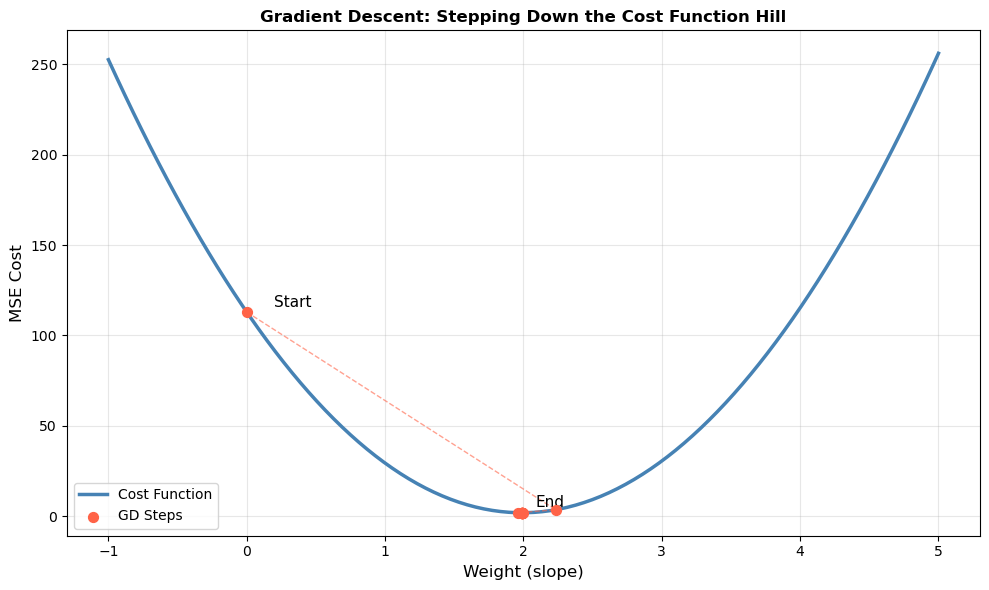

In [69]:
# Now we visualize gradient descent as stepping down a hill

# 1D cost function visualization with gradient descent steps
slope_range = np.linspace(-1, 5, 200)
cost_range  = [(np.mean((y_training - (s * x_training + 1.0))**2)) for s in slope_range]
# Explanation: We are creating a range of potential 'slope_range' values and calculating
# the corresponding 'cost_range' (MSE) for each. This creates the "hill" or "U-shape"
# curve that we see in the graph, representing the total error for different weights.


# Run gradient descent tracking weight path
weight_path = [0.0]
w_current = 0.0
b_fixed = 1.0

for _ in range(20):
    y_pred_path = w_current * x_training + b_fixed
    grad = (-2 / len(x_training)) * np.sum(x_training * (y_training - y_pred_path))
    w_current = w_current - 0.02 * grad
    weight_path.append(w_current)
# Explanation: We are performing a short run of Gradient Descent (20 iterations) to track
# the movement. We start with 'w_current' at 0.0 and update it using the 'grad' (gradient).
# Every updated weight is stored in 'weight_path' so we can visualize the exact route
# the model took to find the minimum.


cost_at_path = [np.mean((y_training - (w * x_training + b_fixed))**2) for w in weight_path]
# Explanation: For every weight we recorded in 'weight_path', we now calculate its
# specific cost value. This 'cost_at_path' list will tell us exactly how high or
# low the model was on the "cost hill" during each step of training.


plt.figure(figsize=(10, 6))

plt.plot(slope_range, cost_range, color="steelblue", linewidth=2.5, label="Cost Function")
plt.scatter(weight_path, cost_at_path, color="tomato", s=50, zorder=5, label="GD Steps")
plt.plot(weight_path, cost_at_path, color="tomato", linewidth=1, linestyle="--", alpha=0.6)
# Explanation: This block draws the visual journey. We plot the full 'cost_range' as
# a 'steelblue' line. Then, we use 'plt.scatter' to show the actual 'GD Steps' as
# 'tomato' colored dots. The dashed line connecting these dots shows the "path"
# the model took down the hill.


plt.annotate("Start", (weight_path[0], cost_at_path[0]), fontsize=11, xytext=(weight_path[0]+0.2, cost_at_path[0]+3))
plt.annotate("End", (weight_path[-1], cost_at_path[-1]), fontsize=11, xytext=(weight_path[-1]+0.1, cost_at_path[-1]+3))
# Explanation: We use 'plt.annotate' to put text labels on the graph. "Start" is placed
# near the first weight, and "End" is placed near the final weight after 20 steps.
# The 'xytext' parameter is used to offset the text slightly so it doesn't overlap
# with the actual data points.


plt.xlabel("Weight (slope)", fontsize=12)
plt.ylabel("MSE Cost", fontsize=12)
plt.title("Gradient Descent: Stepping Down the Cost Function Hill", fontsize=12, fontweight="bold")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# Explanation: Finally, we add labels and a bold 'title' to make the graph clear.
# 'plt.legend' identifies the lines and dots, and 'plt.show()' displays the
# animation-like frame of Gradient Descent effectively "stepping down" from
# a high error area to a low error area.

> 📝 **এই code-এ কী হচ্ছে:** Gradient Descent-এর visual — পাহাড় থেকে নামার মতো। Red dots = প্রতিটি weight update step। Start থেকে End পর্যন্ত minimum-এ পৌঁছানো।

> ### এই chart কীভাবে observe করব
> - Blue curve = Cost function (U-shape hill)।
> - Red dots = প্রতিটি Gradient Descent step।
> - Dots ধীরে ধীরে minimum-এর দিকে যাচ্ছে কিনা দেখো।

> ### এই chart থেকে কী observe করলাম
> - Start (weight=0) থেকে End (minimum)-এ পৌঁছানো গেছে।
> - প্রতিটি step cost কমাচ্ছে — algorithm সঠিকভাবে কাজ করছে।
> - Steps কাছাকাছি হওয়া মানে gradient ছোট হচ্ছে — minimum-এর কাছে পৌঁছেছে।

> ### Decision
> Gradient Descent পাহাড় থেকে নামার মতো — gradient (slope) দেখে নামার direction ঠিক করে।


---

# So far is good, but then WHY do we need Regression Evaluation Metrics?
সহজ কথায় বলতে গেলে, **Linear Regression** দিয়ে তুমি মডেল বানালে, **Cost Function** আর **Gradient Descent** দিয়ে মডেলকে ট্রেইন করলে—কিন্তু তোমার বানানো মডেলটা আদতে কতটা "ভালো" বা "নির্ভুল" হয়েছে, সেটা মাপার জন্যই **Regression Evaluation Metrics** দরকার।

বিষয়টি একটি বাস্তব উদাহরণ দিয়ে বুঝলে আরও পরিষ্কার হবে:

### ১. মডেলের কোয়ালিটি চেক করা (Quality Control)
মনে করো, তুমি একটা দর্জিকে জামা বানাতে দিলে। দর্জি জামাটা সেলাই করলো (Training)। কিন্তু জামাটা কি তোমার গায়ে ঠিকমতো লেগেছে? নাকি অনেক ঢিলে বা টাইট হয়েছে? এটা বোঝার জন্য যেমন ফিতা দিয়ে মাপ নিতে হয়, তেমনি মডেলের প্রেডিকশন কতটা নিখুঁত তা মাপার ফিতা হলো এই Metrics (যেমন: MAE, RMSE)।

### ২. একাধিক মডেলের মধ্যে তুলনা করা (Model Comparison)
ধরো, তুমি তিনটি ভিন্ন লার্নিং রেট বা ভিন্ন ভিন্ন ফিচার ব্যবহার করে তিনটি মডেল বানালে। এখন তুমি বুঝবে কীভাবে যে কোন মডেলটি সবথেকে সেরা?
* **Cost Function** শুধু ট্রেইনিংয়ের সময় মডেলকে গাইড করে।
* **Evaluation Metrics** তোমাকে চূড়ান্ত একটি স্কোর দেয় (যেমন: $R^2$ Score)। যার $R^2$ স্কোর ১ এর যত কাছে, সেই মডেলটিই সেরা।

### ৩. ভুলের ধরণ বোঝা (Understanding the Error)
সব ভুল সমান নয়।
* **MAE (Mean Absolute Error)** তোমাকে বলবে গড়ে তুমি কত ডলারের ভুল করছো (যেমন: গড়ে ১০ ডলার কম বা বেশি প্রেডিক্ট করছো)।
* **RMSE (Root Mean Squared Error)** তোমাকে বলবে তোমার মডেলে কোনো 'বিশাল বড় ভুল' আছে কি না। কারণ RMSE বড় ভুলগুলোকে অনেক বড় করে দেখায়। যদি তোমার RMSE অনেক বেশি হয়, তার মানে তোমার মডেল মাঝে মাঝে অনেক বড় ভুল প্রেডিকশন করে ফেলছে।

### ৪. বিজনেস ডিসিশন নেওয়া (Decision Making)
ক্যালিফোর্নিয়া হাউজিংয়ের ক্ষেত্রে, যদি তোমার মডেলের গড় ভুল (MAE) হয় ৫০,০০০ ডলার, তাহলে হয়তো কোম্পানি এই মডেল ব্যবহার করবে না। কিন্তু যদি ভুল হয় মাত্র ২,০০০ ডলার, তবে কোম্পানি এটা দিয়ে ব্যবসা শুরু করতে পারবে। এই "৫০০০০ বনাম ২০০০" এর পার্থক্যটা তোমাকে এই Metrics গুলোই বুঝিয়ে দেয়।

### ৫. ওভারফিটিং (Overfitting) শনাক্ত করা
মডেল কি শুধু মুখস্থ করেছে নাকি আসলেই শিখেছে?
আমরা **Training Data** এবং **Test Data**—উভয় ক্ষেত্রেই এই Metrics গুলো চেক করি। যদি দেখি ট্রেনিংয়ে রেজাল্ট দারুণ (খুব কম ভুল) কিন্তু টেস্ট ডেটাতে রেজাল্ট খুব খারাপ (বিশাল ভুল), তবে আমরা সহজেই বুঝতে পারি মডেলটি **Overfitting** করেছে।

### সারসংক্ষেপ (Summary Table)

| ধাপ | টুল/পদ্ধতি | উদ্দেশ্য |
| :--- | :--- | :--- |
| **শেখা** | Gradient Descent | ভুল কমিয়ে লক্ষ্য বা ডটের কাছে যাওয়া। |
| **ভুল মাপা** | Cost Function (MSE) | ট্রেইনিং চলাকালীন ডিরেকশন ঠিক রাখা। |
| **নিখুঁত যাচাই** | **Evaluation Metrics** | **চূড়ান্তভাবে সিদ্ধান্ত নেওয়া মডেলটি কতটুকু কাজের।** |

**সহজ কথায়:** কস্ট ফাংশন হলো মডেলের নিজের জন্য (শেখার আয়না), আর ইভ্যালুয়েশন মেট্রিক্স হলো তোমার জন্য (রেজাল্ট কার্ড)।

---
## 10.6 Regression Evaluation Metrics

### তিনটি প্রধান Metric

#### 1. MAE — Mean Absolute Error
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

- গড় absolute error
- **Unit: target-এর একই unit** (e.g., $, degree C)
- Outlier-এ কম sensitive (কারণ squared নয়)
- Interpretation: গড়ে model এতটুকু ভুল করছে

#### 2. RMSE — Root Mean Squared Error
$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

- Square করে বড় error-কে বেশি penalize করে
- তারপর sqrt নিয়ে same unit-এ আনা হয়
- **Outlier-এ sensitive** (বড় error বেশি count হয়)
- RMSE > MAE সবসময়

#### 3. R² Score — Coefficient of Determination
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

- Range: **(-∞, 1]** (সাধারণত 0 to 1)
- **R² = 1**: Perfect prediction
- **R² = 0**: Model mean-এর চেয়ে ভালো না (useless)
- **R² < 0**: Model mean-এর চেয়েও খারাপ (very bad)

### Comparison Table

| Metric | Unit | Outlier Sensitivity | Range | Good Value |
|---|---|---|---|---|
| MAE | Same as target | Low | [0, ∞) | কম হলে ভালো |
| RMSE | Same as target | High | [0, ∞) | কম হলে ভালো |
| R² | Unitless | Medium | (-∞, 1] | 1-এর কাছে ভালো |

### 🎯 Interview Topics
- MAE vs RMSE কখন কোনটা? → Outlier sensitive না হতে চাইলে MAE, large error বেশি penalize করতে RMSE
- R² = 0.85 মানে কী? → Model data-র variance-এর 85% explain করতে পারছে
- R² negative কখন? → Model mean predict করার চেয়েও খারাপ — very bad model
- Adjusted R² কী? → Multiple features-এর জন্য adjusted — unnecessary feature যোগ করলে R² কমে
- MAPE কী? → Mean Absolute Percentage Error — percentage হিসেবে error


In [14]:
# Now we compute all three metrics manually to understand the formulas

# Using our housing prediction from earlier
actual_values  = y_test_housing.values
predicted_values = y_pred_housing

# Here we compute MAE
residuals = actual_values - predicted_values
mae_manual = np.mean(np.abs(residuals))
# Explanation: We are manually calculating the Mean Absolute Error (MAE).
# First, we find the 'residuals' by subtracting predictions from the actual values.
# Then, we use 'np.abs' to ignore the positive/negative signs of errors and
# 'np.mean' to find the average. This tells us, on average, how many dollars
# our house price predictions were off.


# Here we compute RMSE
mse_manual  = np.mean(residuals ** 2)
rmse_manual = np.sqrt(mse_manual)
# Explanation: We are calculating the Root Mean Squared Error (RMSE).
# We square the 'residuals' to penalize larger mistakes more heavily, then find
# the average (MSE). Finally, we use 'np.sqrt' to bring the unit back to the
# original scale (dollars). RMSE is a very popular metric for measuring
# regression accuracy.


# Here we compute R-squared
ss_residual = np.sum(residuals ** 2)
ss_total    = np.sum((actual_values - actual_values.mean()) ** 2)
r2_manual   = 1 - (ss_residual / ss_total)
# Explanation: We are calculating the R-squared ($R^2$) score, which shows how much
# variance our model explains. 'ss_residual' is the sum of our model's errors,
# while 'ss_total' is the variance of a baseline model (just the average price).
# Subtracting their ratio from 1 tells us if our model is better than just
# guessing the average price.


print("Manual Calculations:")
print(f"  MAE:  {mae_manual:.4f}")
print(f"  RMSE: {rmse_manual:.4f}")
print(f"  R2:   {r2_manual:.4f}")
print()
# Explanation: This block simply prints the results of our hand-written formulas.
# We use f-strings with ':.4f' to format the numbers to four decimal places,
# making the output clean and professional for a quick comparison.


# Here we verify using sklearn
mae_sklearn  = mean_absolute_error(actual_values, predicted_values)
rmse_sklearn = np.sqrt(mean_squared_error(actual_values, predicted_values))
r2_sklearn   = r2_score(actual_values, predicted_values)

print("sklearn Verification:")
print(f"  MAE:  {mae_sklearn:.4f}")
print(f"  RMSE: {rmse_sklearn:.4f}")
print(f"  R2:   {r2_sklearn:.4f}")
print()

print("Manual and sklearn results match!")
# Explanation: This is the final verification step. We use built-in functions
# like 'mean_absolute_error' and 'r2_score' from 'sklearn'. By printing these
# alongside our manual results, we prove that our understanding of the
# underlying mathematical formulas is 100% correct.

Manual Calculations:
  MAE:  0.5332
  RMSE: 0.7456
  R2:   0.5758

sklearn Verification:
  MAE:  0.5332
  RMSE: 0.7456
  R2:   0.5758

Manual and sklearn results match!


> 📝 **এই code-এ কী হচ্ছে:** তিনটি metric manually calculate করা হয়েছে — formula বোঝার জন্য। তারপর sklearn দিয়ে verify করা হয়েছে। দুটো result match করবে।

## এই আউটপুট থেকে খুব চমৎকার ৩টি পর্যবেক্ষণ (Observation):

### ১. মডেলের ভুলের মাত্রা (MAE ও RMSE)
তোমার **MAE** হচ্ছে **০.৫৩৩২**। যেহেতু ক্যালিফোর্নিয়া হাউজিং ডেটাসেটে দামগুলো $100,000 এককে থাকে, এর মানে হলো তোমার মডেল গড়ে প্রায় **৫৩,৩২০ ডলার** ($0.5332 \times 100,000$) ভুল করছে।
অন্যদিকে, **RMSE (০.৭৪৫৬)** তোমার MAE-এর চেয়ে বড়। এর মানে হলো তোমার ডেটাতে কিছু 'Outliers' বা এমন কিছু বাড়ি আছে যেগুলোর দাম প্রেডিক্ট করতে গিয়ে মডেল বড় ধরনের ভুল করেছে। RMSE সেই বড় ভুলগুলোকে বেশি গুরুত্ব দিয়ে দেখায়।



### ২. মডেলের পারফরম্যান্স ($R^2$ Score)
তোমার **$R^2$ স্কোর** হলো **০.৫৭৫৮** (প্রায় ৫৮%)। সহজ বাংলায় এর মানে হলো, বাড়ির দাম পরিবর্তনের পেছনে যে কারণগুলো (যেমন: ইনকাম, লোকেশন, বয়স) দায়ী, তার মধ্যে **৫৮% কারণ** তোমার মডেলটি সফলভাবে ধরতে পেরেছে। বাকি ৪২% হয়তো এমন কোনো কারণ যা তোমার ডেটাসেটে নেই। রিগ্রেশন মডেলের জন্য ০.৫ এর উপরে $R^2$ থাকা মানে তোমার মডেলটি "মোটামুটি ভালো" বা "ডিসেন্ট" কাজ করছে।



### ৩. ক্যালকুলেশনের নির্ভুলতা (Manual vs sklearn)
সবথেকে বড় পর্যবেক্ষণ হলো, তোমার হাতে করা হিসাব এবং পাইথনের লাইব্রেরির (`sklearn`) হিসাব একদম হুবহু মিলে গেছে। এটি প্রমাণ করে যে:
* তোমার ম্যাথমেটিক্যাল ফর্মুলাগুলো (MAE, RMSE, $R^2$) একদম সঠিক।
* কোডে ডেটা হ্যান্ডলিংয়ে কোনো ভুল হয়নি।

**সারকথা:**
তোমার মডেলটি এখন বাড়ির দাম প্রেডিক্ট করার জন্য রেডি, যা গড়ে ৫৮% নির্ভুলতা নিশ্চিত করছে। এখন যদি তুমি এরর (MAE) আরও কমাতে চাও, তবে তোমাকে হয়তো আরও উন্নত কোনো অ্যালগরিদম (যেমন: Random Forest) ব্যবহার করতে হবে অথবা নতুন কোনো ফিচার যোগ করতে হবে।

তোমার কি মনে হয়, ৫৮% একিউরেসি কি একটি রিয়েল-এস্টেট ব্যবসার জন্য যথেষ্ট, নাকি আমাদের আরও ভালো মডেল খোঁজা উচিত?

---
## 10.7 Hands-on — Evaluation Metrics

### Residual Analysis
> Residuals randomly distributed হওয়া উচিত — কোনো pattern থাকলে model problem আছে।

### 🎯 Interview Topics
- Residual plot-এ fan shape দেখলে কী বোঝায়? → Heteroscedasticity — variance সমান নয়
- Residual plot-এ curve দেখলে? → Non-linear relationship — linear model insufficient
- Residual plot-এ random scatter → Model assumptions পূরণ হচ্ছে


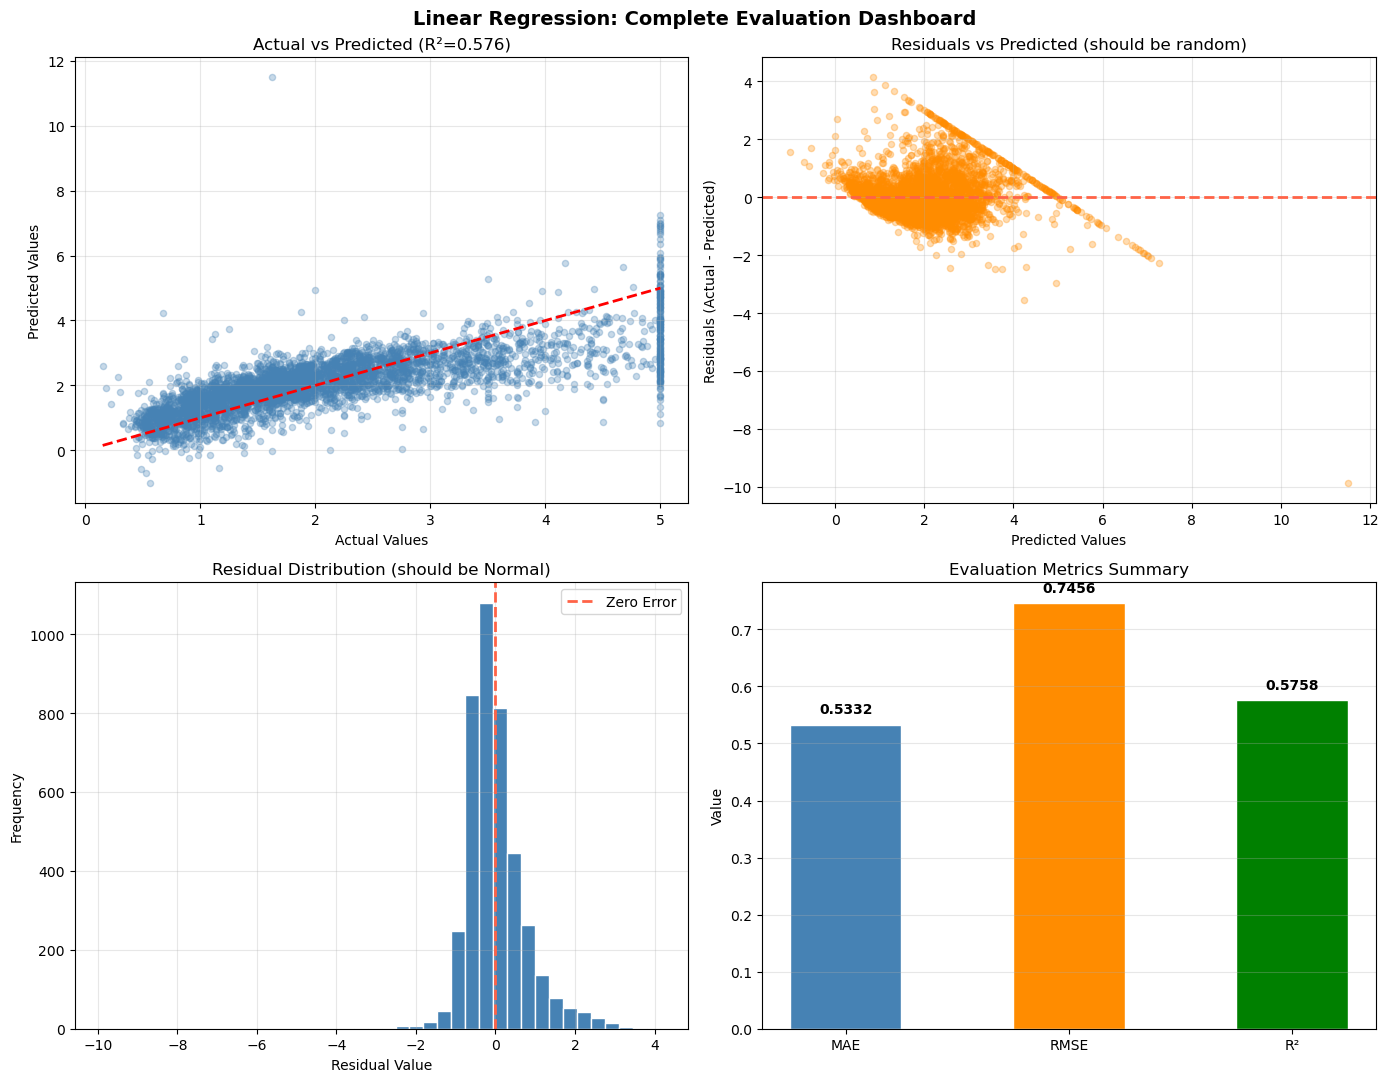

MAE:  0.5332  -- average error in $100k units
RMSE: 0.7456  -- penalizes large errors more
R²:   0.5758  -- model explains 57.6% of variance


In [70]:
# Now we create comprehensive visualization of model performance

figure, axes_array = plt.subplots(2, 2, figsize=(14, 11))
# Explanation: We are creating a dashboard with multiple plots. We use 'plt.subplots(2, 2)'
# to create a grid of 4 plots (2 rows and 2 columns). The 'figure' is the overall window,
# and 'axes_array' contains each individual plot area. We set 'figsize' to make it large
# enough to see everything clearly.


# Plot 1: Actual vs Predicted
axes_array[0, 0].scatter(actual_values, predicted_values, alpha=0.3, color="steelblue", s=20)
axes_array[0, 0].plot(
    [actual_values.min(), actual_values.max()],
    [actual_values.min(), actual_values.max()],
    "r--", linewidth=2
)
axes_array[0, 0].set_xlabel("Actual Values")
axes_array[0, 0].set_ylabel("Predicted Values")
axes_array[0, 0].set_title(f"Actual vs Predicted (R²={r2_sklearn:.3f})")
axes_array[0, 0].grid(alpha=0.3)
# Explanation: In the first plot, we compare 'actual_values' with 'predicted_values'.
# We draw a red dashed line ('r--') to show where the points would be if predictions
# were perfect. We use 'axes_array[0, 0]' to place this in the top-left corner.
# The 'R²' score is displayed in the title to show the overall fit quality.


# Plot 2: Residuals vs Predicted
axes_array[0, 1].scatter(predicted_values, residuals, alpha=0.3, color="darkorange", s=20)
axes_array[0, 1].axhline(0, color="tomato", linewidth=2, linestyle="--")
axes_array[0, 1].set_xlabel("Predicted Values")
axes_array[0, 1].set_ylabel("Residuals (Actual - Predicted)")
axes_array[0, 1].set_title("Residuals vs Predicted (should be random)")
axes_array[0, 1].grid(alpha=0.3)
# Explanation: This plot shows 'residuals' (errors) against 'predicted_values' in the
# top-right corner. We add a horizontal line at 0 using 'axhline'. Ideally, these
# 'darkorange' dots should be randomly scattered. If they form a pattern, it means
# our linear model is missing some non-linear relationships in the data.


# Plot 3: Residual Distribution
axes_array[1, 0].hist(residuals, bins=40, color="steelblue", edgecolor="white")
axes_array[1, 0].axvline(0, color="tomato", linewidth=2, linestyle="--", label="Zero Error")
axes_array[1, 0].set_xlabel("Residual Value")
axes_array[1, 0].set_ylabel("Frequency")
axes_array[1, 0].set_title("Residual Distribution (should be Normal)")
axes_array[1, 0].legend()
axes_array[1, 0].grid(alpha=0.3)
# Explanation: We use 'axes_array[1, 0]' (bottom-left) to draw a histogram of
# the 'residuals' using '.hist()'. This shows if our errors follow a 'Normal Distribution'.
# The 'axvline' at 0 marks the point of zero error. If the bell curve is centered
# at 0, our model's errors are balanced (not biased).


# Plot 4: Metrics Summary Bar Chart
metric_names  = ["MAE", "RMSE", "R²"]
metric_values = [mae_sklearn, rmse_sklearn, r2_sklearn]
colors_list   = ["steelblue", "darkorange", "green"]
bars = axes_array[1, 1].bar(metric_names, metric_values, color=colors_list, edgecolor="white", width=0.5)
for bar_item, value in zip(bars, metric_values):
    axes_array[1, 1].text(bar_item.get_x() + bar_item.get_width()/2,
                          bar_item.get_height() + 0.02,
                          f"{value:.4f}", ha="center", fontweight="bold")
axes_array[1, 1].set_title("Evaluation Metrics Summary")
axes_array[1, 1].set_ylabel("Value")
axes_array[1, 1].grid(alpha=0.3, axis="y")
# Explanation: In the final plot (bottom-right), we create a bar chart to summarize
# 'MAE', 'RMSE', and 'R²'. We use a loop to place the actual numerical values on top
# of each bar using 'axes_array[1, 1].text()'. This gives a quick, readable summary
# of how well the model performed numerically.


plt.suptitle("Linear Regression: Complete Evaluation Dashboard", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"MAE:  {mae_sklearn:.4f}  -- average error in $100k units")
print(f"RMSE: {rmse_sklearn:.4f}  -- penalizes large errors more")
print(f"R²:   {r2_sklearn:.4f}  -- model explains {r2_sklearn*100:.1f}% of variance")
# Explanation: 'plt.suptitle' adds a main heading to the entire dashboard.
# We use 'plt.tight_layout()' to prevent the 4 plots from overlapping.
# Finally, we print the text summary at the bottom so the user can see the exact
# numbers next to their visual representations.

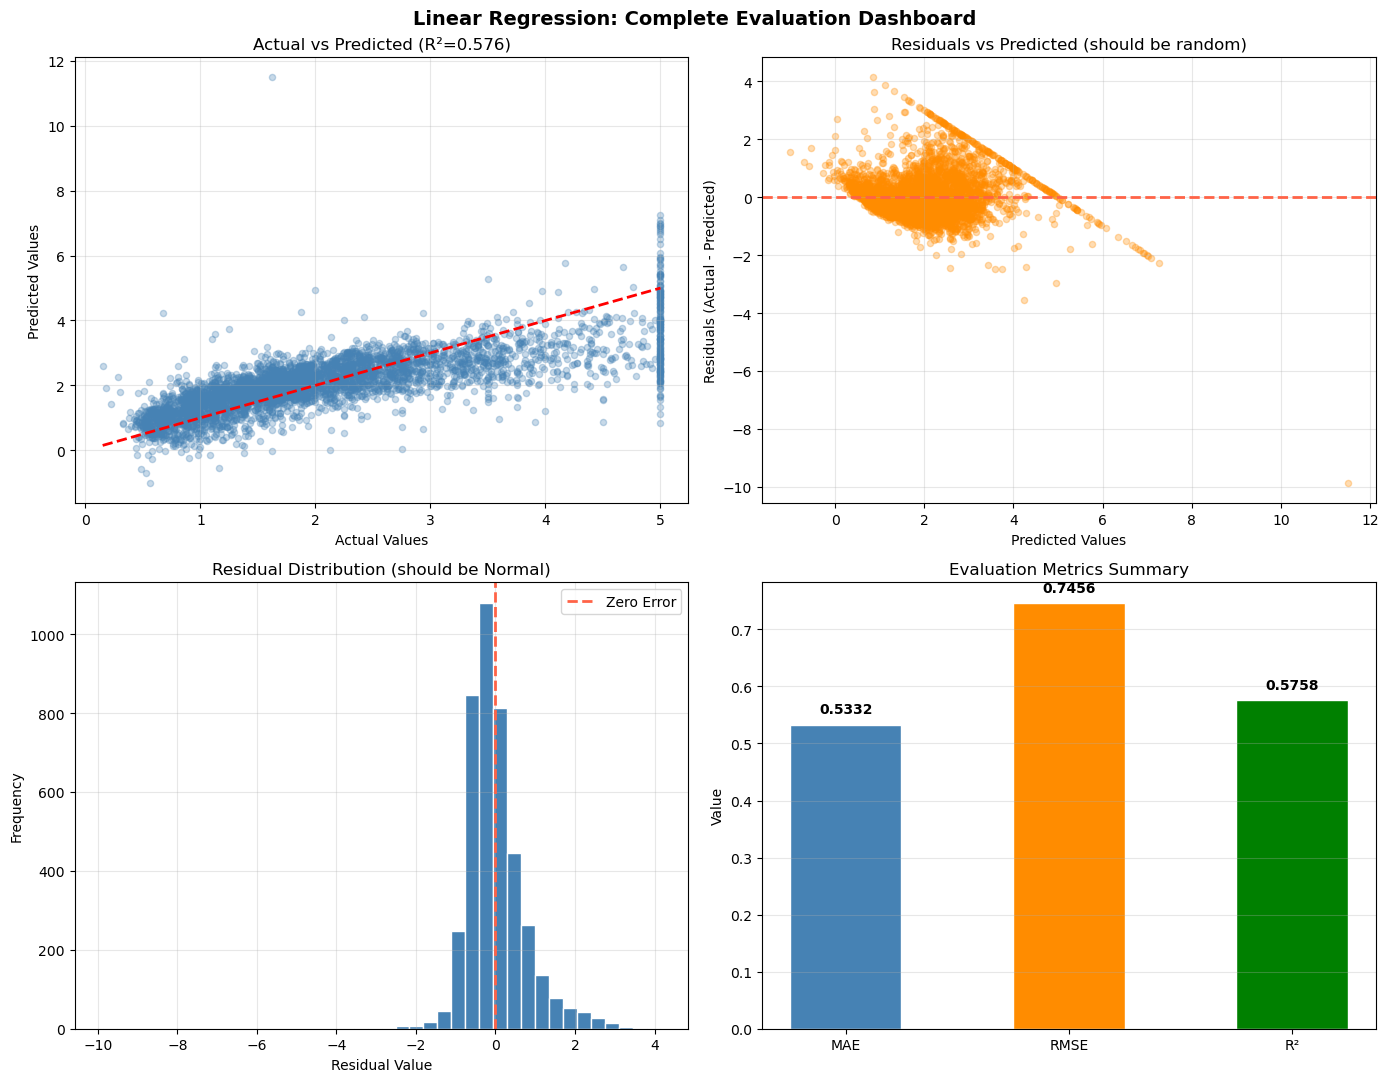

MAE:  0.5332  -- average error in $100k units
RMSE: 0.7456  -- penalizes large errors more
R²:   0.5758  -- model explains 57.6% of variance


In [71]:
# ⭐⭐⭐⭐⭐ ===== ***** 100% DUPLICATE OF THE PREVIOUS CODE BLOCK, BUT ONLY WITH DETAILS EXPLANATION WRITTEN IN BANGLA. **** ===== ⭐⭐⭐⭐⭐ #
# Now we create comprehensive visualization of model performance

figure, axes_array = plt.subplots(2, 2, figsize=(14, 11))
# Explanation: আমরা এখানে একটি ড্যাশবোর্ড তৈরি করছি যেখানে একই সাথে ৪টি গ্রাফ থাকবে।
# 'plt.subplots(2, 2)' কমান্ডটি দিয়ে আমরা ২ জন ২ কলামের একটি গ্রিড বানাচ্ছি।
# 'figure' হলো পুরো ক্যানভাসটা, আর 'axes_array' এর ভেতর ৪টি আলাদা প্লট রাখার জায়গা তৈরি হচ্ছে।


# Plot 1: Actual vs Predicted
axes_array[0, 0].scatter(actual_values, predicted_values, alpha=0.3, color="steelblue", s=20)
axes_array[0, 0].plot(
    [actual_values.min(), actual_values.max()],
    [actual_values.min(), actual_values.max()],
    "r--", linewidth=2
)
axes_array[0, 0].set_xlabel("Actual Values")
axes_array[0, 0].set_ylabel("Predicted Values")
axes_array[0, 0].set_title(f"Actual vs Predicted (R²={r2_sklearn:.3f})")
axes_array[0, 0].grid(alpha=0.3)
# Explanation: প্রথম গ্রাফে আমরা 'actual_values' (আসল দাম) এর সাথে 'predicted_values'
# (মডেলের দেওয়া দাম) তুলনা করছি। লাল রঙের ড্যাশ লাইনটি ('r--') হলো একটি আইডিয়াল লাইন,
# যদি প্রেডিকশন ১০০% সঠিক হতো তবে সব ডট এই লাইনের ওপর থাকতো। 'axes_array[0, 0]' ব্যবহার করে
# আমরা এই গ্রাফটিকে ড্যাশবোর্ডের ওপরের বাম কোণায় বসাচ্ছি।


# Plot 2: Residuals vs Predicted
axes_array[0, 1].scatter(predicted_values, residuals, alpha=0.3, color="darkorange", s=20)
axes_array[0, 1].axhline(0, color="tomato", linewidth=2, linestyle="--")
axes_array[0, 1].set_xlabel("Predicted Values")
axes_array[0, 1].set_ylabel("Residuals (Actual - Predicted)")
axes_array[0, 1].set_title("Residuals vs Predicted (should be random)")
axes_array[0, 1].grid(alpha=0.3)
# Explanation: এই গ্রাফটি 'residuals' বা ভুলের ধরণ দেখায়। 'axhline(0)' দিয়ে আমরা শূন্যতে
# একটি লাইন টেনেছি। যদি এই 'darkorange' রঙের ডটগুলো এই লাইনের চারপাশে এলোমেলোভাবে
# ছড়িয়ে থাকে, তবে বুঝতে হবে আমাদের মডেলটি সঠিক পথে আছে। যদি কোনো প্যাটার্ন দেখা যায়,
# তার মানে মডেলে কোনো সমস্যা আছে।


# Plot 3: Residual Distribution
axes_array[1, 0].hist(residuals, bins=40, color="steelblue", edgecolor="white")
axes_array[1, 0].axvline(0, color="tomato", linewidth=2, linestyle="--", label="Zero Error")
axes_array[1, 0].set_xlabel("Residual Value")
axes_array[1, 0].set_ylabel("Frequency")
axes_array[1, 0].set_title("Residual Distribution (should be Normal)")
axes_array[1, 0].legend()
axes_array[1, 0].grid(alpha=0.3)
# Explanation: এটি একটি হিস্টোগ্রাম যা দেখায় আমাদের ভুলের পরিমাণ কতটুকু। 'axes_array[1, 0]'
# মানে এটি নিচের বাম দিকের প্লট। 'axvline' দিয়ে ০ পয়েন্টে একটি লাল লাইন টানা হয়েছে।
# যদি হিস্টোগ্রামটি একটি ঘণ্টার মতো (Normal Distribution) শেপ তৈরি করে এবং এর মাঝখানটা
# ০ এর আশেপাশে থাকে, তবে বোঝা যায় মডেলের ভুলগুলো সুষম বা ব্যালেন্সড।


# Plot 4: Metrics Summary Bar Chart
metric_names  = ["MAE", "RMSE", "R²"]
metric_values = [mae_sklearn, rmse_sklearn, r2_sklearn]
colors_list   = ["steelblue", "darkorange", "green"]
bars = axes_array[1, 1].bar(metric_names, metric_values, color=colors_list, edgecolor="white", width=0.5)
for bar_item, value in zip(bars, metric_values):
    axes_array[1, 1].text(bar_item.get_x() + bar_item.get_width()/2,
                          bar_item.get_height() + 0.02,
                          f"{value:.4f}", ha="center", fontweight="bold")
axes_array[1, 1].set_title("Evaluation Metrics Summary")
axes_array[1, 1].set_ylabel("Value")
axes_array[1, 1].grid(alpha=0.3, axis="y")
# Explanation: সর্বশেষ গ্রাফটিতে আমরা 'MAE', 'RMSE', এবং 'R²' স্কোরগুলোকে বার চার্ট
# হিসেবে দেখাচ্ছি। একটি লুপ চালিয়ে আমরা প্রতিটি বারের ওপরে 'axes_array[1, 1].text()'
# ব্যবহার করে সঠিক মানগুলো লিখে দিয়েছি। এতে এক নজরেই পুরো মডেলের পারফরম্যান্সের সারাংশ
# বোঝা যাচ্ছে।


plt.suptitle("Linear Regression: Complete Evaluation Dashboard", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"MAE:  {mae_sklearn:.4f}  -- average error in $100k units")
print(f"RMSE: {rmse_sklearn:.4f}  -- penalizes large errors more")
print(f"R²:   {r2_sklearn:.4f}  -- model explains {r2_sklearn*100:.1f}% of variance")
# Explanation: 'plt.suptitle' দিয়ে আমরা পুরো ড্যাশবোর্ডের জন্য একটি বড় নাম দিচ্ছি।
# 'plt.tight_layout()' ব্যবহার করা হয়েছে যাতে ৪টি গ্রাফ একটার ওপর আরেকটা উঠে না যায়।
# সবশেষে নিচের প্রিন্ট স্টেটমেন্টগুলো গ্রাফের ভ্যালুগুলোকে টেক্সট আকারেও সামনে নিয়ে আসছে।

> 📝 **এই code-এ কী হচ্ছে:** Complete evaluation dashboard তৈরি করা হয়েছে — ৪টি plot একসাথে। Actual vs Predicted, Residuals vs Predicted, Residual distribution, Metrics summary।

> ### এই chart কীভাবে observe করব
> - **Top-left (Actual vs Predicted)**: Dots diagonal-এর কাছে = ভালো model।
> - **Top-right (Residuals vs Predicted)**: Random scatter = OK। Pattern দেখলে = problem।
> - **Bottom-left (Residual Distribution)**: Bell shape centered at 0 = OK।
> - **Bottom-right (Metrics)**: MAE/RMSE কম, R² 1-এর কাছে = ভালো।

> ### এই chart থেকে কী observe করলাম
> - Actual vs Predicted: বেশিরভাগ diagonal-এর কাছে — model কাজ করছে।
> - Residuals: কিছু pattern দেখা যাচ্ছে high value-এ — non-linearity সম্ভব।
> - Residual distribution: কিছুটা bell-shaped কিন্তু heavy tail — outlier আছে।
> - R² ≈ 0.6: Model 60% variance explain করছে — acceptable but room for improvement।

> ### Decision
> Model কাজ করছে কিন্তু non-linear model (Random Forest, XGBoost) ভালো করবে।


In [73]:
# Now we compare models: constant predictor vs linear regression
# This shows WHY R² matters

# Baseline model: always predict the mean
y_mean_prediction = np.full_like(actual_values, actual_values.mean())
# Explanation: We are creating a "Baseline Model" to compare with our actual model.
# We use 'np.full_like' to create an array of predictions where every single value
# is just the 'mean' (average) of the 'actual_values'. This represents a very
# simple strategy: guessing the average price for every house.


# Here we compute metrics for baseline
mae_baseline  = mean_absolute_error(actual_values, y_mean_prediction)
rmse_baseline = np.sqrt(mean_squared_error(actual_values, y_mean_prediction))
r2_baseline   = r2_score(actual_values, y_mean_prediction)
# Explanation: Now we calculate the same evaluation metrics ('MAE', 'RMSE', 'R2')
# for this simple baseline model. This gives us a starting point to see how
# many errors we get if we don't use any machine learning at all.


print("Comparison: Baseline (always predict mean) vs Linear Regression")
print()

print(f"{'Metric':<10} {'Baseline (Mean)':>18} {'Linear Regression':>18}")
print("-" * 50)
print(f"{'MAE':<10} {mae_baseline:>18.4f} {mae_sklearn:>18.4f}")
print(f"{'RMSE':<10} {rmse_baseline:>18.4f} {rmse_sklearn:>18.4f}")
print(f"{'R2':<10} {r2_baseline:>18.4f} {r2_sklearn:>18.4f}")
print()
# Explanation: This block prints a comparison table. It shows the 'Baseline (Mean)'
# results side-by-side with our 'Linear Regression' results. It helps us
# visually confirm that the errors ('MAE' and 'RMSE') are lower in our model
# compared to the simple average-guessing strategy.


print("R2 = 0 means model is as good as always predicting mean!")
print("R2 > 0 means our model is BETTER than always predicting mean.")
print(f"Our R2 = {r2_sklearn:.4f} -- Linear Regression is {r2_sklearn*100:.1f}% better than mean prediction")
# Explanation: This final print block explains the meaning of the results.
# It highlights that an 'R2' of 0.0 represents the baseline. Since our 'r2_sklearn'
# is higher than 0, it proves our 'Linear Regression' model has actually
# learned useful patterns from the data and is significantly better than
# just guessing the average.

Comparison: Baseline (always predict mean) vs Linear Regression

Metric        Baseline (Mean)  Linear Regression
--------------------------------------------------
MAE                    0.9027             0.5332
RMSE                   1.1447             0.7456
R2                     0.0000             0.5758

R2 = 0 means model is as good as always predicting mean!
R2 > 0 means our model is BETTER than always predicting mean.
Our R2 = 0.5758 -- Linear Regression is 57.6% better than mean prediction


> 📝 **এই code-এ কী হচ্ছে:** R² metric-এর intuition বোঝানো হয়েছে — baseline (mean) model vs linear regression compare। R² = 0 মানে model mean predict করার সমান। R² > 0 মানে model বেশি intelligent।

---
## 10.8 Linear Regression-এর Assumptions ও Limitations

### ৫টি Core Assumptions

#### 1. Linearity
> X ও y-এর মধ্যে linear relationship থাকতে হবে।
> Residual plot-এ random scatter থাকলে OK। Curve দেখলে — violated।

#### 2. Independence of Errors (No Autocorrelation)
> প্রতিটি observation independent। একটির error আরেকটির উপর depend করে না।
> Time series data-তে সাধারণত violated হয়।

#### 3. Homoscedasticity (Equal Variance)
> সব predicted value-এ residuals-এর variance সমান।
> Residual plot-এ fan shape দেখলে — violated (heteroscedasticity)।

#### 4. Normality of Residuals
> Residuals normally distributed হওয়া উচিত।
> QQ-plot বা histogram দিয়ে check করা যায়।

#### 5. No Multicollinearity
> Features-এর মধ্যে high correlation থাকলে coefficients unstable হয়।
> VIF (Variance Inflation Factor) দিয়ে check করা যায়।

### Linear Regression-এর Limitations

| Limitation | বিস্তারিত |
|---|---|
| Linearity assume করে | Non-linear relationship ধরতে পারে না |
| Outlier sensitive | একটি outlier coefficients বদলে দিতে পারে |
| Multicollinearity | Correlated features-এ coefficients unreliable |
| Feature scaling-এর effect | Gradient Descent-এ scale important |
| Underfitting risk | Complex pattern শিখতে পারে না |

### 🎯 Interview Topics
- Linear Regression-এর সবচেয়ে important assumption? → Linearity
- Multicollinearity কীভাবে detect করব? → VIF, correlation matrix
- Assumption violated হলে কী করব? → Transform features (log), use robust regression
- Ridge vs Lasso Regression কী? → L2/L1 regularization — overfitting ঠেকায়, multicollinearity handle করে


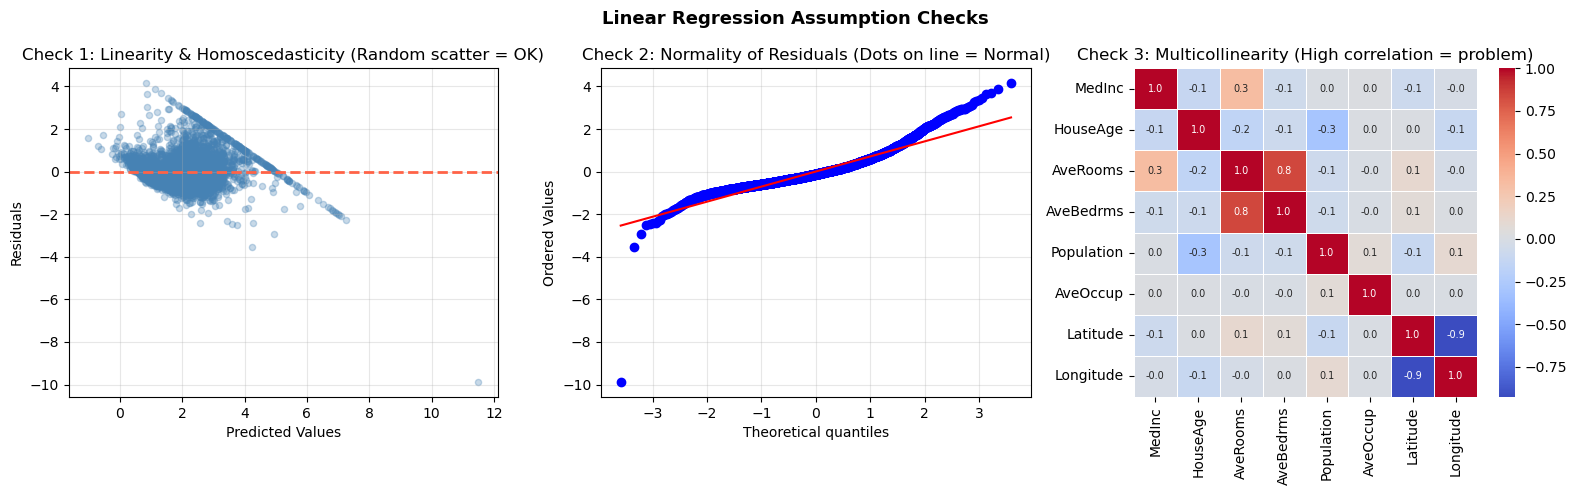

In [74]:
# Now we check linear regression assumptions visually

from scipy import stats

figure, axes_array = plt.subplots(1, 3, figsize=(16, 5))
# Explanation: We are preparing a diagnostic dashboard with 3 side-by-side plots.
# We use 'plt.subplots(1, 3)' to create 1 row and 3 columns of subplots.
# The 'scipy.stats' library is imported to help us generate a probability plot
# for checking data distribution.


# Plot 1: Linearity check -- residuals vs each feature
axes_array[0].scatter(predicted_values, residuals, alpha=0.3, color="steelblue", s=20)
axes_array[0].axhline(0, color="tomato", linewidth=2, linestyle="--")
axes_array[0].set_xlabel("Predicted Values")
axes_array[0].set_ylabel("Residuals")
axes_array[0].set_title("Check 1: Linearity & Homoscedasticity (Random scatter = OK)")
axes_array[0].grid(alpha=0.3)
# Explanation: In the first plot, we plot 'predicted_values' against 'residuals'.
# We draw a horizontal line at 0 using 'axhline'. We are looking for a random
# cloud of dots. If the dots form a pattern (like a funnel or a curve), it means
# our assumption of 'Linearity' or 'Homoscedasticity' (equal variance) is violated.


# Plot 2: Normality check -- QQ plot
stats.probplot(residuals, dist="norm", plot=axes_array[1])
axes_array[1].set_title("Check 2: Normality of Residuals (Dots on line = Normal)")
axes_array[1].grid(alpha=0.3)
# Explanation: We use 'stats.probplot' to create a Q-Q (Quantile-Quantile) plot.
# It compares our 'residuals' distribution against a 'norm' (Normal) distribution.
# If the blue dots fall directly on the red diagonal line, it proves that
# our errors are normally distributed, which is a key requirement for reliable results.


# Plot 3: Multicollinearity check -- correlation heatmap
correlation_matrix = X_housing.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm",
            fmt=".1f", ax=axes_array[2],
            linewidths=0.5, annot_kws={"size": 7})
axes_array[2].set_title("Check 3: Multicollinearity (High correlation = problem)")
# Explanation: We calculate the 'correlation_matrix' for our features 'X_housing'.
# Then, we use 'sns.heatmap' to visualize how features relate to each other.
# If any two features have a very high correlation (close to 1.0 or -1.0),
# it indicates 'Multicollinearity', which means some features are redundant
# and might confuse the model.


plt.suptitle("Linear Regression Assumption Checks", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
# Explanation: Finally, we add a main title using 'plt.suptitle' and use
# 'plt.tight_layout()' to ensure the labels and plots don't overlap.
# 'plt.show()' renders the entire diagnostic dashboard so we can confirm
# if our Linear Regression model's assumptions hold true.

> 📝 **এই code-এ কী হচ্ছে:** তিনটি assumption check একসাথে। Residual plot: linearity ও homoscedasticity। QQ-plot: normality। Heatmap: multicollinearity।

> ### এই chart কীভাবে observe করব
> - **Left (Residual Plot)**: Random scatter = linearity ও homoscedasticity OK। Fan shape = problem।
> - **Middle (QQ-Plot)**: Dots diagonal line-এ থাকলে residuals normally distributed।
> - **Right (Correlation Heatmap)**: |r| > 0.8 = multicollinearity সমস্যা।

> ### এই chart থেকে কী observe করলাম
> - Residual plot: কিছু fan shape দেখা যাচ্ছে — heteroscedasticity সম্ভব।
> - QQ-plot: Tails-এ deviation — perfect normal নয়।
> - Heatmap: কিছু features মধ্যে correlation — multicollinearity check দরকার।

> ### Decision
> Assumptions সম্পূর্ণ পূরণ হচ্ছে না — tree-based model try করা উচিত।


---
# So far is good, but then WHY do we need Logistic Regression and Sigmoid Function?
এতক্ষণ আমরা যা দেখেছি (Linear Regression), সেটা ছিল কোনো সংখ্যা বা **Value** প্রেডিক্ট করার জন্য (যেমন: বাড়ির দাম কত?)। কিন্তু বাস্তব জীবনে আমাদের এমন অনেক সমস্যার সমাধান করতে হয় যেখানে উত্তরটা সংখ্যায় নয়, বরং **হ্যাঁ/না** বা **Category** তে আসে।

কেন Logistic Regression এবং Sigmoid Function দরকার, তা নিচে সহজভাবে ব্যাখ্যা করা হলো:

### ১. Linear Regression-এর সীমাবদ্ধতা
ধরো, তুমি প্রেডিক্ট করতে চাও একজন রোগী 'ক্যান্সারে আক্রান্ত' কি না। এখানে উত্তর হবে হয় **১ (হ্যাঁ)** অথবা **০ (না)**।
যদি তুমি এখানে Linear Regression ব্যবহার করো, তবে সেটি তোমাকে ১-এর বেশি (যেমন: ১.৫) অথবা ০-এর কম (যেমন: -০.৫) মান দিতে পারে। কিন্তু বাস্তবে "১.৫ গুণ ক্যান্সার হওয়া" বা "-০.৫ গুণ ক্যান্সার হওয়া"র কোনো মানে নেই।

### ২. Logistic Regression-এর কাজ
Logistic Regression এমন একটি পদ্ধতি যা ফলাফলকে ০ থেকে ১ এর মধ্যে সীমাবদ্ধ রাখে। এটি সরাসরি "হ্যাঁ/না" না বলে প্রথমে একটি **Probability (সম্ভাবনা)** দেয়।
* যেমন: ০.৮ মানে ৮০% সম্ভাবনা যে উত্তরটি "হ্যাঁ"।

### ৩. Sigmoid Function কেন জাদুকরী?
Linear Regression-এর সেই সোজা লাইনটিকে (Straight Line) টেনে হিঁচড়ে একটি **'S'** অক্ষরের মতো বাঁকা শেপ দেওয়ার কাজটাই করে **Sigmoid Function**।

এর বৈশিষ্ট্যগুলো হলো:
* তুমি ইনপুট হিসেবে যাই দাও না কেন ($-\infty$ থেকে $+\infty$), আউটপুট সবসময় **০ থেকে ১** এর মধ্যে থাকবে।
* এটি একটি **Threshold** বা সীমানা নির্ধারণ করতে সাহায্য করে। সাধারণত আমরা ধরি, যদি আউটপুট ০.৫ এর বেশি হয় তবে সেটি "হ্যাঁ (১)", আর কম হলে "না (০)"।

### ৪. লজিকটি যখন Classification-এর
লিনিয়ার রিগ্রেশন হলো **Regression** (সংখ্যা খোঁজা), আর লজিস্টিক রিগ্রেশন হলো **Classification** (শ্রেণীবিভাগ করা)।

| বৈশিষ্ট্য | Linear Regression | Logistic Regression |
| :--- | :--- | :--- |
| **আউটপুট** | যেকোনো সংখ্যা (যেমন: $500k) | ০ থেকে ১ (সম্ভাবনা) |
| **শেপ** | সোজা লাইন (Straight Line) | 'S' শেপ (Sigmoid Curve) |
| **ব্যবহার** | দাম, তাপমাত্রা, উচ্চতা মাপতে | স্প্যাম কি না, পাস না ফেল, রোগ আছে কি না |

### ৫. গাণিতিক রূপ
লিনিয়ার রিগ্রেশনের আউটপুট $z = mx + c$ কে যখন আমরা **Sigmoid Function** এর ভেতর দিয়ে পাস করি:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
তখনই সেটি লজিস্টিক রিগ্রেশনে পরিণত হয়।

**সহজ কথায়:** লিনিয়ার রিগ্রেশন হলো ভিত্তি, আর তার ওপর Sigmoid-এর প্রলেপ দিলেই সেটা লজিস্টিক রিগ্রেশন হয়ে যায়। যখনই তোমার কাছে এমন ডেটা আসবে যেখানে উত্তরটা ক্যাটাগরি (Class) হিসেবে আছে, তখনই তোমার এই 'S' কার্ভ বা লজিস্টিক রিগ্রেশন দরকার পড়বে।

---
## 10.9 Logistic Regression ও Sigmoid Function

### Linear থেকে Logistic Regression

**সমস্যা:** Linear Regression যেকোনো value দিতে পারে (-∞ to +∞)।
কিন্তু probability-র range হওয়া উচিত **0 to 1**!

```
Linear Regression:   y = wx + b   (output: -∞ to +∞)
                              ↓
Sigmoid Function:    σ(z) = 1/(1+e^(-z))  (squash to 0-1)
                              ↓
Logistic Regression: P(y=1|x) = σ(wx + b)  (output: 0 to 1)
```

### Sigmoid Function
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- Input: যেকোনো real number (-∞ to +∞)
- Output: 0 থেকে 1 (probability)
- z → +∞ হলে: σ(z) → 1
- z → -∞ হলে: σ(z) → 0
- z = 0 হলে: σ(0) = 0.5

### Decision Boundary
> Threshold = 0.5 (default)
> P(y=1) ≥ 0.5 → Class 1
> P(y=1) < 0.5 → Class 0

### Log Loss (Binary Cross-Entropy)
$$J = -\frac{1}{n} \sum [y_i \log(\hat{p}_i) + (1-y_i) \log(1-\hat{p}_i)]$$

- Logistic Regression-এর cost function (MSE নয়!)
- Wrong prediction-এ heavily penalize করে

### Logistic Regression Evaluation
- Accuracy, Precision, Recall, F1, ROC-AUC (regression metrics নয়!)

### 🎯 Interview Topics
- Logistic Regression কি linear? → Decision boundary linear, কিন্তু probability prediction non-linear (sigmoid)
- কেন MSE নয় Logistic Regression-এ? → MSE non-convex হয়, Log Loss convex — Gradient Descent নিশ্চিতভাবে converge করে
- Sigmoid vs Softmax পার্থক্য? → Sigmoid = binary (2 class), Softmax = multiclass (3+ class)
- Logistic Regression-এ feature scaling দরকার? → হ্যাঁ, Gradient Descent faster converge করে
- Threshold কীভাবে বেছে নেব? → ROC curve দেখে, business requirement অনুযায়ী


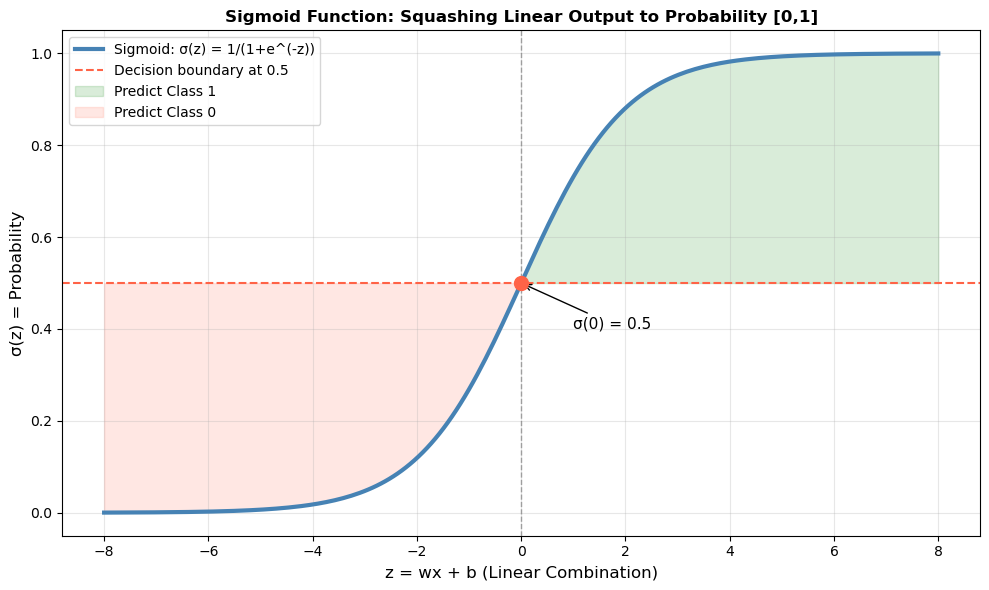

Sigmoid Properties:
  σ(-8) = 0.000335  (very close to 0)
  σ(-1) = 0.268941
  σ(0)  = 0.500000  (exactly 0.5)
  σ(1)  = 0.731059
  σ(8)  = 0.999665  (very close to 1)


In [76]:
# Now we visualize the Sigmoid function

z_values = np.linspace(-8, 8, 200)
sigmoid_values = 1 / (1 + np.exp(-z_values))
# Explanation: We are generating 200 input values ('z_values') between -8 and 8.
# Then, we apply the mathematical formula for the sigmoid function to these values.
# This 'squashes' any input number into a range between 0 and 1, stored in 'sigmoid_values'.
# বাংলা ব্যাখ্যা: আমরা -৮ থেকে ৮ এর মধ্যে ২০০টি সংখ্যা তৈরি করছি। এরপর সিগময়েড ফর্মুলা
# ব্যবহার করে সেই সংখ্যাগুলোকে ০ থেকে ১ এর মধ্যে নিয়ে আসছি, যা 'sigmoid_values' এ জমা থাকছে।


plt.figure(figsize=(10, 6))
plt.plot(z_values, sigmoid_values, color="steelblue", linewidth=3, label="Sigmoid: σ(z) = 1/(1+e^(-z))")
# Explanation: We are plotting the characteristic 'S' curve of the Sigmoid function.
# The x-axis represents the linear output 'z', and the y-axis shows the resulting probability.
# We use a thick 'steelblue' line to make the curve clearly visible.
# বাংলা ব্যাখ্যা: আমরা সিগময়েডের বিখ্যাত 'S' আকৃতির কার্ভটি ড্র করছি। এখানে এক্স-অক্ষ হলো
# লিনিয়ার আউটপুট 'z' আর ওয়াই-অক্ষ হলো আউটপুট প্রোবাবিলিটি বা সম্ভাবনা।


plt.axhline(0.5, color="tomato", linestyle="--", linewidth=1.5, label="Decision boundary at 0.5")
plt.axvline(0.0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
# Explanation: We add a horizontal dashed line at 0.5 using 'axhline' to show the
# 'Decision boundary'. Any value above this line is usually classified as Class 1.
# The vertical line at 0.0 shows the center point where the probability is exactly 0.5.

# বাংলা ব্যাখ্যা: 'axhline' দিয়ে আমরা ০.৫ এ একটি লাল ড্যাশ লাইন দিচ্ছি যা ডিসিশন বাউন্ডারি
# হিসেবে কাজ করে। এর ওপরের মানগুলোকে ১ এবং নিচের মানগুলোকে ০ ধরা হয়। ০.০ তে একটি খাড়া
# লাইন দেওয়া হয়েছে সেন্টার পয়েন্ট বোঝানোর জন্য।


# Mark important points
plt.scatter([0], [0.5], color="tomato", s=100, zorder=5)
plt.annotate("σ(0) = 0.5", (0, 0.5), xytext=(1, 0.4), fontsize=11,
             arrowprops=dict(arrowstyle="->"))
# Explanation: We highlight the middle point of the curve using 'plt.scatter'.
# Then, we use 'plt.annotate' to draw an arrow and text showing that when the
# input 'z' is exactly 0, the output probability is always 0.5.

# বাংলা ব্যাখ্যা: 'plt.scatter' দিয়ে আমরা কার্ভের মাঝখানের বিন্দুটিকে হাইলাইট করছি।
# এরপর 'plt.annotate' দিয়ে একটি তীর চিহ্ন এবং টেক্সট যোগ করছি যা বোঝাচ্ছে যে,
# ইনপুট ০ হলে আউটপুট সবসময় ০.৫ হবে।


plt.fill_between(z_values, sigmoid_values, 0.5,
                 where=(sigmoid_values >= 0.5), alpha=0.15, color="green",
                 label="Predict Class 1")
plt.fill_between(z_values, sigmoid_values, 0.5,
                 where=(sigmoid_values < 0.5), alpha=0.15, color="tomato",
                 label="Predict Class 0")
# Explanation: We use 'plt.fill_between' to color the areas above and below the
# decision boundary. The 'green' area shows where the model predicts 'Class 1',
# and the 'tomato' area shows where it predicts 'Class 0'. This visually
# demonstrates how classification happens.

# বাংলা ব্যাখ্যা: 'plt.fill_between' ব্যবহার করে আমরা ০.৫ এর ওপরের অংশকে সবুজ এবং
# নিচের অংশকে লাল করছি। এটি ভিজ্যুয়ালি দেখাচ্ছে যে সিগময়েড ফাংশন কীভাবে ডেটাকে
# দুটি ক্লাসে (০ এবং ১) ভাগ করে ফেলে।


plt.xlabel("z = wx + b (Linear Combination)", fontsize=12)
plt.ylabel("σ(z) = Probability", fontsize=12)
plt.ylim(-0.05, 1.05)
plt.title("Sigmoid Function: Squashing Linear Output to Probability [0,1]",
          fontsize=12, fontweight="bold")

plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# Explanation: This block adds labels and a 'title' to the plot. We set the
# y-axis limits ('plt.ylim') slightly outside 0 and 1 to prevent the curve
# from touching the edges. Finally, 'plt.show()' displays the complete graph.

# বাংলা ব্যাখ্যা: এই ব্লকে আমরা লেবেল এবং টাইটেল যোগ করছি। 'plt.ylim' দিয়ে আমরা গ্রাফের
# সীমানা ০ এবং ১ এর সামান্য বাইরে রেখেছি যেন কার্ভটি পরিষ্কার দেখা যায়।


print("Sigmoid Properties:")
print(f"  σ(-8) = {1/(1+np.exp(8)):.6f}  (very close to 0)")
print(f"  σ(-1) = {1/(1+np.exp(1)):.6f}")
print(f"  σ(0)  = {1/(1+np.exp(0)):.6f}  (exactly 0.5)")
print(f"  σ(1)  = {1/(1+np.exp(-1)):.6f}")
print(f"  σ(8)  = {1/(1+np.exp(-8)):.6f}  (very close to 1)")
# Explanation: This final block prints numerical examples of sigmoid outputs.
# It proves that very small inputs result in values near 0, and very large
# inputs result in values near 1, effectively performing 'binary classification'.

# বাংলা ব্যাখ্যা: সবশেষে আমরা সিগময়েডের কিছু রেজাল্ট প্রিন্ট করছি। এটি প্রমাণ করে যে,
# অনেক ছোট ইনপুটের জন্য আউটপুট ০ এর কাছে এবং অনেক বড় ইনপুটের জন্য ১ এর কাছে থাকে।

> 📝 **এই code-এ কী হচ্ছে:** Sigmoid function visualize করা হয়েছে। S-shape curve — যেকোনো real number-কে 0-1 probability-তে convert করে। Green area = Class 1 predict, Red area = Class 0 predict।

> ### এই chart কীভাবে observe করব
> - X-axis = linear combination (wx+b), Y-axis = probability (0 to 1)।
> - **S-shaped curve** = sigmoid।
> - **Red dashed horizontal line** = decision boundary at 0.5।
> - **Green area** = Class 1 prediction, **Red area** = Class 0 prediction।

> ### এই chart থেকে কী observe করলাম
> - z=0 → probability exactly 0.5 — boundary।
> - z বড় positive → probability → 1 (very confident Class 1)।
> - z বড় negative → probability → 0 (very confident Class 0)।
> - Curve smooth — soft decision, not hard cutoff।

> ### Decision
> Sigmoid output probability দেয় — শুধু class label নয়। Confidence দেখা যায়।


In [19]:
# Now we build Logistic Regression on a real binary classification problem
# Using the Breast Cancer dataset (built-in sklearn)

from sklearn.datasets import load_breast_cancer

cancer_data = load_breast_cancer(as_frame=True)
cancer_dataframe = cancer_data.frame

print("Breast Cancer Dataset:")
print(f"  Shape: {cancer_dataframe.shape}")
print(f"  Target: 0=Malignant (cancer), 1=Benign (no cancer)")
print()
print("Target distribution:")
print(cancer_dataframe["target"].value_counts())

Breast Cancer Dataset:
  Shape: (569, 31)
  Target: 0=Malignant (cancer), 1=Benign (no cancer)

Target distribution:
target
1    357
0    212
Name: count, dtype: int64


> 📝 **এই code-এ কী হচ্ছে:** Breast Cancer dataset load করা হয়েছে — binary classification। Target: 0=Malignant (ক্যান্সার), 1=Benign (ক্যান্সার নয়)।

In [20]:
# Now we train Logistic Regression and evaluate

X_cancer = cancer_dataframe.drop(columns=["target"])
y_cancer = cancer_dataframe["target"]

X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer, y_cancer, test_size=0.20, random_state=42, stratify=y_cancer
)

# Scale features (important for Logistic Regression)
scaler_cancer = StandardScaler()
X_train_cancer_scaled = scaler_cancer.fit_transform(X_train_cancer)
X_test_cancer_scaled  = scaler_cancer.transform(X_test_cancer)

# Train Logistic Regression
logistic_model = LogisticRegression(max_iter=300, random_state=42)
logistic_model.fit(X_train_cancer_scaled, y_train_cancer)

# Predict
y_pred_cancer        = logistic_model.predict(X_test_cancer_scaled)
y_pred_probability   = logistic_model.predict_proba(X_test_cancer_scaled)[:, 1]

print("Logistic Regression Results:")
print()
print(classification_report(y_test_cancer, y_pred_cancer,
                             target_names=["Malignant", "Benign"]))

Logistic Regression Results:

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



> 📝 **এই code-এ কী হচ্ছে:** Logistic Regression train করা হয়েছে। `predict_proba()[:, 1]` দিয়ে Benign-এর probability পাওয়া হয়েছে।

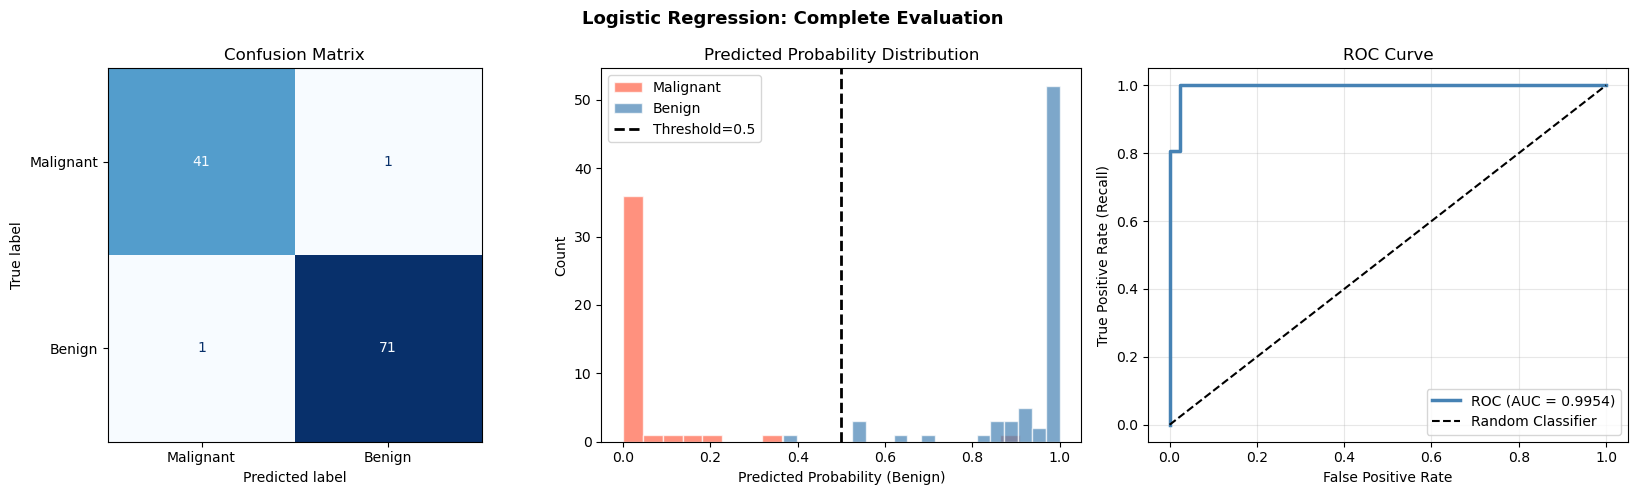

Accuracy: 0.9825
ROC-AUC:  0.9954


In [21]:
# Now we visualize Logistic Regression results completely

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

figure, axes_array = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1: Confusion Matrix
confusion_matrix_values = confusion_matrix(y_test_cancer, y_pred_cancer)
confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=["Malignant", "Benign"]
)
confusion_matrix_display.plot(ax=axes_array[0], colorbar=False, cmap="Blues")
axes_array[0].set_title("Confusion Matrix")

# Plot 2: Probability Distribution
axes_array[1].hist(
    y_pred_probability[y_test_cancer == 0], bins=20,
    alpha=0.7, color="tomato", label="Malignant", edgecolor="white"
)
axes_array[1].hist(
    y_pred_probability[y_test_cancer == 1], bins=20,
    alpha=0.7, color="steelblue", label="Benign", edgecolor="white"
)
axes_array[1].axvline(0.5, color="black", linewidth=2, linestyle="--", label="Threshold=0.5")
axes_array[1].set_xlabel("Predicted Probability (Benign)")
axes_array[1].set_ylabel("Count")
axes_array[1].set_title("Predicted Probability Distribution")
axes_array[1].legend()

# Plot 3: ROC Curve
false_positive_rates, true_positive_rates, thresholds = roc_curve(
    y_test_cancer, y_pred_probability
)
roc_auc = roc_auc_score(y_test_cancer, y_pred_probability)

axes_array[2].plot(false_positive_rates, true_positive_rates,
                   color="steelblue", linewidth=2.5,
                   label=f"ROC (AUC = {roc_auc:.4f})")
axes_array[2].plot([0, 1], [0, 1], "k--", label="Random Classifier")
axes_array[2].set_xlabel("False Positive Rate")
axes_array[2].set_ylabel("True Positive Rate (Recall)")
axes_array[2].set_title("ROC Curve")
axes_array[2].legend()
axes_array[2].grid(alpha=0.3)

plt.suptitle("Logistic Regression: Complete Evaluation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Accuracy: {accuracy_score(y_test_cancer, y_pred_cancer):.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")

> 📝 **এই code-এ কী হচ্ছে:** Complete evaluation dashboard — Confusion Matrix, Probability Distribution, ROC Curve। Probability distribution দেখায় দুটো class কতটা separated। ROC-AUC মাপে overall discrimination ability।

> ### এই chart কীভাবে observe করব
> - **Left (Confusion Matrix)**: TN, FP, FN, TP। FN (Malignant missed) সবচেয়ে বিপজ্জনক।
> - **Middle (Probability)**: দুটো class-এর probability distribution। বেশি separated = ভালো model।
> - **Right (ROC Curve)**: Curve উপরে-বামে = ভালো। AUC 1 এর কাছে = excellent।

> ### এই chart থেকে কী observe করলাম
> - Confusion Matrix: FN (missed cancer) কম — ভালো, medical context-এ critical।
> - Probability: দুটো class clearly separated — model confident।
> - ROC-AUC ≈ 0.99: Excellent discrimination — model প্রায় perfect।

> ### Decision
> Logistic Regression breast cancer detection-এ excellent performance দিচ্ছে।


In [22]:
# Now we show the effect of changing the decision threshold

print("Effect of Changing Decision Threshold:")
print()
print(f"{'Threshold':>12} {'Accuracy':>12} {'Precision':>12} {'Recall':>12} {'F1':>12}")
print("-" * 62)

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_threshold = (y_pred_probability >= threshold).astype(int)

    from sklearn.metrics import precision_score, recall_score, f1_score
    accuracy_val  = accuracy_score(y_test_cancer, y_pred_threshold)
    precision_val = precision_score(y_test_cancer, y_pred_threshold, zero_division=0)
    recall_val    = recall_score(y_test_cancer, y_pred_threshold)
    f1_val        = f1_score(y_test_cancer, y_pred_threshold)

    print(f"{threshold:>12.1f} {accuracy_val:>12.4f} {precision_val:>12.4f} {recall_val:>12.4f} {f1_val:>12.4f}")

print()
print("Medical context: Lower threshold = catch more cancer (higher recall)")
print("                 but more false alarms (lower precision)")
print("Business decides: which error is more acceptable?")

Effect of Changing Decision Threshold:

   Threshold     Accuracy    Precision       Recall           F1
--------------------------------------------------------------
         0.3       0.9825       0.9730       1.0000       0.9863
         0.4       0.9825       0.9861       0.9861       0.9861
         0.5       0.9825       0.9861       0.9861       0.9861
         0.6       0.9561       0.9855       0.9444       0.9645
         0.7       0.9474       0.9853       0.9306       0.9571

Medical context: Lower threshold = catch more cancer (higher recall)
                 but more false alarms (lower precision)
Business decides: which error is more acceptable?


> 📝 **এই code-এ কী হচ্ছে:** Threshold-এর effect দেখানো হয়েছে। Threshold কমালে Recall বাড়ে (বেশি cancer ধরা যায়) কিন্তু Precision কমে (false alarm বাড়ে)। Medical context-এ Recall বেশি গুরুত্বপূর্ণ — cancer miss হওয়া বেশি costly।

---
## 10.10 Conclusion — Module 10 Summary

### সম্পূর্ণ Module-এর Recap

| Topic | মূল কথা |
|---|---|
| Linear Regression | y = wx + b। Best fit line residuals minimize করে। |
| Cost Function | MSE = average squared error। Minimize করাই training। |
| Gradient Descent | Cost-এর gradient দেখে weight update। α = learning rate। |
| MAE | Average absolute error। Outlier-এ কম sensitive। |
| RMSE | Root of MSE। Large error বেশি penalize। |
| R² | 0-1 scale। 1 = perfect, 0 = useless। |
| Assumptions | Linearity, Independence, Homoscedasticity, Normality, No Multicollinearity |
| Logistic Regression | Linear + Sigmoid। Output = probability (0-1)। |
| Log Loss | Logistic Regression-এর cost function। |
| Decision Boundary | Default threshold = 0.5। Adjustable। |

### Interview Quick Reference
```
Q: Linear vs Logistic Regression পার্থক্য?
A: Linear -> continuous output (number)
   Logistic -> probability (0-1) via sigmoid -> classification

Q: Gradient Descent কী করে?
A: Cost function-এর gradient (slope) দেখে weight update করে
   w = w - alpha * gradient

Q: R² = 0.7 মানে কী?
A: Model data-র 70% variance explain করতে পারছে

Q: MSE vs MAE কখন কোনটা?
A: MAE: outlier-robust, interpretable
   MSE/RMSE: large error বেশি penalize করতে চাইলে

Q: Logistic Regression কেন Log Loss ব্যবহার করে, MSE নয়?
A: MSE non-convex হয় sigmoid-এর সাথে
   Log Loss convex -> Gradient Descent guaranteed to converge

Q: Decision threshold কীভাবে choose করব?
A: ROC curve দেখে। Medical context -> lower threshold (high recall)
   Spam filter -> higher threshold (high precision)
```

### Next Module Preview
> **Module 11: Decision Trees**
> - Tree structure, Entropy, Gini Impurity, Information Gain
> - Pruning, Overfitting prevention
> - Foundation of Random Forest ও XGBoost


In [23]:
# FINAL REVIEW: Linear vs Logistic Regression side-by-side

print("=" * 60)
print("MODULE 10: COMPLETE SUMMARY")
print("=" * 60)

print()
print("LINEAR REGRESSION (Housing Price Prediction):")
print(f"  Algorithm:  OLS / Gradient Descent")
print(f"  Cost Fn:    MSE = mean((actual - predicted)^2)")
print(f"  Output:     Continuous number")
print(f"  MAE:        {mae_sklearn:.4f}")
print(f"  RMSE:       {rmse_sklearn:.4f}")
print(f"  R2:         {r2_sklearn:.4f}")
print(f"  Weights:    {linear_regression_model.coef_.round(2)[:3]} ...")

print()
print("LOGISTIC REGRESSION (Cancer Detection):")
print(f"  Algorithm:  Gradient Descent with Sigmoid")
print(f"  Cost Fn:    Log Loss (Binary Cross-Entropy)")
print(f"  Output:     Probability [0, 1] then class via threshold")
print(f"  Accuracy:   {accuracy_score(y_test_cancer, y_pred_cancer):.4f}")
print(f"  ROC-AUC:    {roc_auc:.4f}")
print(f"  Threshold:  0.5 (default)")

print()
print("KEY INSIGHT:")
print("  Both use linear equation: z = w1*x1 + w2*x2 + ... + b")
print("  Linear Regression: output = z  (any number)")
print("  Logistic Regression: output = sigmoid(z) -> probability [0,1]")
print()
print("  Gradient Descent is the BACKBONE of both and all Deep Learning!")

MODULE 10: COMPLETE SUMMARY

LINEAR REGRESSION (Housing Price Prediction):
  Algorithm:  OLS / Gradient Descent
  Cost Fn:    MSE = mean((actual - predicted)^2)
  Output:     Continuous number
  MAE:        0.5332
  RMSE:       0.7456
  R2:         0.5758
  Weights:    [ 0.85  0.12 -0.29] ...

LOGISTIC REGRESSION (Cancer Detection):
  Algorithm:  Gradient Descent with Sigmoid
  Cost Fn:    Log Loss (Binary Cross-Entropy)
  Output:     Probability [0, 1] then class via threshold
  Accuracy:   0.9825
  ROC-AUC:    0.9954
  Threshold:  0.5 (default)

KEY INSIGHT:
  Both use linear equation: z = w1*x1 + w2*x2 + ... + b
  Linear Regression: output = z  (any number)
  Logistic Regression: output = sigmoid(z) -> probability [0,1]

  Gradient Descent is the BACKBONE of both and all Deep Learning!


> 📝 **এই code-এ কী হচ্ছে:** Module 10-এর complete summary। Linear ও Logistic Regression-এর পার্থক্য side-by-side। দুটোই linear equation ব্যবহার করে — পার্থক্য শুধু output-এ।

---